# Data import and preprocessing
## Constants, packages and paths

In [133]:
# Core constants for LPG supply chain processing
default_LPG_price = 0.6  # USD/kg
STS_cost = 0.1  # US$/kg
pre_bottling_cost = 0.2  # 20% TO BE MODIFIED
ferry_cost_per_km = 0.78  # US$/ton/straight line km
ferry_time_per_km = 0.071  # hours/straight line km
CRUDE_BARREL_TO_TONS = 7.33  # barrel of crude per ton
BUFFER_KM = 10  # km radius for spatial buffer queries

# Core dependencies for tabular, spatial, and raster work
import pandas as pd
import geopandas as gpd
from pathlib import Path
import numpy as np
import rasterio
from rasterio.mask import mask as raster_mask
from shapely.geometry import Point, box
from skimage.graph import MCP_Geometric
from pyproj import Geod
from onstove.layer import RasterLayer

# Workspace data folder for intermediate inputs and outputs
data_dir = Path("dataset_first_step")
data_dir.mkdir(exist_ok=True)

# Default gpkg and layer names used when user files are missing
DEFAULT_GPKG = data_dir / "default.gpkg"
DEFAULT_LAYERS = {
    'refineries': 'refineries',
    'ports': 'ports',
    'gas_plants': 'gas_plants',
    'primary_storage': 'primary_storage',
    'border_points': 'border_points',
}

# Paths
dataset_big_dir = Path("dataset_big")
friction_raster_path = data_dir / "friction_moto.tif"
lpg_price_raster_path = data_dir / "fob_per_kg_fake.tif"
national_shares_raster_path = data_dir / "national_shares.tif"
lpg_import_cost_raster_path = data_dir / "lpg_import_cost.tif"
lpg_household_shares_raster_path = data_dir / "lpg_household_shares.tif"
output_gpkg = data_dir / "beginning.gpkg"
output_gpkg_alt = data_dir / "beginning_new.gpkg"
output_excel_path = data_dir / "storage_allocation.xlsx"
output_image_path = data_dir / "galga_flow.png"
beginning_path = output_gpkg
filling_points_path = dataset_big_dir / "filling_point_clients.gpkg"
filling_assigned_path = dataset_big_dir / "filling_point_assigned.gpkg"
primary_storage_path = output_gpkg

# Global flags and thresholds
MIN_SHARE_PCT = 1.0
BORDER_NEAR_KM = 5
BORDER_POINT_TIME_HOURS = 39
DEFAULT_RESIDENCE_DAYS = 15.0
USE_DEFAULT_RESIDENCE_TIME = True  # fixed residence time
USE_DIFFERENTIATED_STORAGE_COSTS = False  # differentiated vs average

# Tanker cost parameters
tanker_capacity_kg = 24000
utilization_factor = 0.85
variable_cost_per_km = 0.635
driver_annual_salary_usd = 2604
salary_multiplier = 1.18
hours_per_day = 8
discount_rate = 0.03  # OnStove uses 0.03 for social perspective, 0.15 for private perspective
tanker_overnight_cost_usd = 197673
tanker_life_years = 35
license_cost_usd = 418
licence_life_years = 5
days_per_year = 330
fixed_loading_unloading_hours = 1.0
tanker_annual_km = 42000

# Storage cost parameters
meals_per_day = 1.0
energy_per_meal_mj = 3.64
efficiency = 0.5
energy_content_mj_per_kg = 45.5
density_kg_per_l = 0.5
storage_overnight_cost_usd_kg = 12.5
storage_installation_fee = 760.0
storage_license_cost_usd = 3952.0
storage_life_years = 50
storage_license_life_years = 3
storage_cap = 0.25



## Create mask layer

In [134]:
# Build mask_layer from the valid footprint of the friction raster
from rasterio.features import shapes
from shapely.geometry import shape
import shapely

friction_mask_path = friction_raster_path
if not friction_mask_path.exists():
    raise FileNotFoundError(f"Missing friction raster for mask creation: {friction_mask_path}")

with rasterio.open(friction_mask_path) as src:
    if src.crs is None:
        raise ValueError("friction_moto.tif has no CRS")

    # Valid data footprint: non-nodata pixels
    valid_mask = src.dataset_mask() > 0
    if not np.any(valid_mask):
        raise ValueError("friction_moto.tif contains no valid pixels to build mask_layer")

    # Convert the raster mask to polygons and dissolve them into one geometry
    mask_shapes = [
        shape(geom)
        for geom, value in shapes(valid_mask.astype(np.uint8), mask=valid_mask, transform=src.transform)
        if value == 1
    ]

    if len(mask_shapes) == 0:
        raise ValueError("Could not extract a valid geometry footprint from friction_moto.tif")

    mask_geom = shapely.union_all(mask_shapes)
    mask_layer = gpd.GeoDataFrame(geometry=[mask_geom], crs=src.crs).to_crs("EPSG:4326")

print(f"Mask layer initialized from friction raster ({len(mask_layer)} geometry)")
print("Constants declared and imports completed")

Mask layer initialized from friction raster (1 geometry)
Constants declared and imports completed


## Functions: data loading and fill missing values

In [135]:
# Load input data with smart defaults
from onstove.layer import VectorLayer, RasterLayer
from shapely.ops import nearest_points
from pyproj import CRS

def _as_vector_layer(gdf, name="mask"):
    """
    Wrap a GeoDataFrame in a VectorLayer for in-memory masking.
    Avoids writing temporary files and keeps attributes intact.
    Returns a VectorLayer ready for VectorLayer.mask.
    """
    vect = VectorLayer(name=name)
    vect.data = gdf.copy()
    return vect


def load_raster_means(raster_path, band_names, mask_gdf):
    """
    Clip each band by mask and compute mean values.
    Returns a single-column DataFrame indexed by band names.
    Raises if any band has no valid pixels inside the mask.
    """
    if not raster_path.exists():
        raise FileNotFoundError(f"Missing raster file: {raster_path}")

    if mask_gdf.crs is None:
        raise ValueError("mask_layer has no CRS")

    mask_vect = _as_vector_layer(mask_gdf, name="mask_layer")
    values = {}

    for band_idx, band_name in enumerate(band_names, start=1):
        raster = RasterLayer(name=f"{raster_path.stem}_{band_name}", path=str(raster_path), band=band_idx)
        raster.mask(mask_vect, crop=True, all_touched=False)

        arr = raster.data.astype(np.float64)
        nodata = raster.meta.get('nodata')
        if nodata is not None:
            if pd.notna(nodata):
                arr[arr == nodata] = np.nan

        mean_val = np.nanmean(arr)
        if np.isnan(mean_val):
            raise ValueError(
                f"Band '{band_name}' in {raster_path.name} has no valid data inside mask_layer"
            )
        values[band_name] = float(mean_val)

    result = pd.DataFrame.from_dict(values, orient='index')
    result.columns = [1]
    return result


def load_or_use_default(gpkg_name, default_gpkg_path, default_layer_name, mask_gdf, data_dir=data_dir):
    """
    Load a layer from user data or defaults, then clip it to mask_gdf.
    Returns a GeoDataFrame with a stable id_supply column.
    No files are written during the fallback path.
    """
    gpkg_path = data_dir / f"{gpkg_name}.gpkg"
    mask_vect = _as_vector_layer(mask_gdf, name="mask_layer")

    if gpkg_path.exists():
        # Phase 1: User data found
        layer = VectorLayer(name=gpkg_name, path=str(gpkg_path))
        layer.mask(mask_vect, keep_geom_type=False)
        gdf = layer.data
        gdf = gdf.reset_index(drop=True)
        gdf['id_supply'] = [f"{gpkg_name}_{i}" for i in range(len(gdf))]
        print(f"{gpkg_name}: loaded and clipped in memory ({len(gdf)} records)")
        return gdf

    # Phase 2: Use default.gpkg layer and clip with mask_layer (no file creation)
    if not default_gpkg_path.exists():
        raise FileNotFoundError(f"Missing default gpkg: {default_gpkg_path}")

    default_gdf = gpd.read_file(default_gpkg_path, layer=default_layer_name)
    default_layer = _as_vector_layer(default_gdf, name=gpkg_name)
    default_layer.mask(mask_vect, keep_geom_type=False)

    gdf = default_layer.data
    gdf = gdf.reset_index(drop=True)
    gdf['id_supply'] = [f"{gpkg_name}_{i}" for i in range(len(gdf))]
    print(f"{gpkg_name}: clipped from default.gpkg/{default_layer_name} in memory ({len(gdf)} records)")
    return gdf


def load_border_points_or_default(mask_gdf, data_dir=data_dir, near_km=BORDER_NEAR_KM):
    """
    Load border points, then keep, snap, or drop by distance to mask_gdf.
    Points within near_km get snapped to the mask boundary.
    Returns a GeoDataFrame with id_supply and original attributes.
    """
    user_path = data_dir / "border_points.gpkg"

    if user_path.exists():
        try:
            points = gpd.read_file(user_path, layer="border_points")
        except Exception:
            points = gpd.read_file(user_path)
        source_name = f"{user_path.name}"
    else:
        if not DEFAULT_GPKG.exists():
            raise FileNotFoundError(f"Missing default gpkg: {DEFAULT_GPKG}")
        points = gpd.read_file(DEFAULT_GPKG, layer=DEFAULT_LAYERS['border_points'])
        source_name = f"default.gpkg/{DEFAULT_LAYERS['border_points']}"

    if points.empty:
        print(f"border_points: loaded 0 records from {source_name}")
        points = points.reset_index(drop=True)
        points['id_supply'] = [f"border_points_{i}" for i in range(len(points))]
        return points

    if mask_gdf.crs is None:
        raise ValueError("mask_layer has no CRS")
    if points.crs is None:
        raise ValueError("border_points has no CRS")

    pts = points.to_crs(mask_gdf.crs).copy()

    pts_m = pts.to_crs("EPSG:3857").copy()
    mask_m = mask_gdf.to_crs("EPSG:3857")
    mask_union_m = mask_m.geometry.union_all()

    inside_count = 0
    moved_count = 0
    dropped_count = 0

    keep_rows = []
    new_geom_m = []

    for idx, geom_m in zip(pts_m.index, pts_m.geometry):
        if geom_m is None or geom_m.is_empty:
            dropped_count += 1
            continue

        if mask_union_m.covers(geom_m):
            inside_count += 1
            keep_rows.append(idx)
            new_geom_m.append(geom_m)
            continue

        dist_m = float(geom_m.distance(mask_union_m))
        if dist_m <= near_km * 1000:
            snapped = nearest_points(geom_m, mask_union_m)[1]
            moved_count += 1
            keep_rows.append(idx)
            new_geom_m.append(snapped)
        else:
            dropped_count += 1

    if len(keep_rows) == 0:
        out = pts.iloc[0:0].copy()
    else:
        out_m = pts_m.loc[keep_rows].copy()
        out_m.geometry = new_geom_m
        out = out_m.to_crs(mask_gdf.crs)

    out = out.reset_index(drop=True)
    out['id_supply'] = [f"border_points_{i}" for i in range(len(out))]
    print(
        f"border_points: loaded from {source_name} | inside={inside_count}, moved_to_mask={moved_count}, dropped_far={dropped_count}"
    )
    return out


def _metric_crs_for_gdf(gdf):
    """
    Return a metric CRS for distance operations.
    If input is projected, return its CRS.
    If geographic, derive a local azimuthal projection from the centroid.
    Raises if CRS is missing or geometry is empty.
    """
    if gdf.crs is None:
        raise ValueError("Input GeoDataFrame has no CRS")
    if not gdf.crs.is_geographic:
        return gdf.crs
    centroid = gdf.geometry.union_all().centroid
    if centroid.is_empty:
        raise ValueError("Cannot derive metric CRS from empty geometry")
    return CRS.from_proj4(
        f"+proj=aeqd +lat_0={centroid.y} +lon_0={centroid.x} +datum=WGS84 +units=m +no_defs"
    )


def _metric_views_for_buffer(gdf, other_gdf):
    """
    Return both layers in a metric CRS for buffering.
    If input is geographic, reproject both to a local metric CRS.
    Otherwise return the inputs unchanged.
    """
    metric_crs = _metric_crs_for_gdf(gdf)
    if gdf.crs.is_geographic:
        return gdf.to_crs(metric_crs), other_gdf.to_crs(metric_crs)
    return gdf, other_gdf


def fill_from_buffer(gdf, default_gdf, cols, buffer_km=BUFFER_KM):
    """
    Fill missing values by searching nearby features within a buffer radius.
    Uses a metric CRS to compute distances safely.
    Keeps original geometry and CRS on output.
    """
    gdf, default_gdf = gdf.copy(), default_gdf.to_crs(gdf.crs)
    if gdf.crs is None or default_gdf.crs is None:
        raise ValueError("Input GeoDataFrame has no CRS")
    gdf_metric, default_metric = _metric_views_for_buffer(gdf, default_gdf)
    buffer_dist = buffer_km * 1000.0

    for col in cols:
        if col not in gdf.columns:
            continue
        missing_idx = gdf[gdf[col].isna() | (gdf[col] == '')].index
        if len(missing_idx) == 0:
            continue

        for idx in missing_idx:
            geom = gdf_metric.loc[idx, 'geometry']
            if geom is None or geom.is_empty:
                continue
            port_buffer = geom.buffer(buffer_dist)
            nearby = default_metric[default_metric.geometry.intersects(port_buffer)]

            if len(nearby) > 0 and col in nearby.columns:
                val = nearby[col].dropna()
                if len(val) > 0:
                    gdf.at[idx, col] = val.iloc[0]
    return gdf


def fill_lpg_price_from_raster(gdf, raster_path, band_index=1, overwrite=False):
    """
    Sample a raster at facility locations and fill LPG_price.
    Handles non-point geometries via centroids.
    Only fills missing values unless overwrite=True.
    """
    out = gdf.copy()

    if out.crs is None:
        raise ValueError("Input GeoDataFrame has no CRS")

    if 'LPG_price' not in out.columns:
        out['LPG_price'] = np.nan

    raster_file = Path(raster_path)
    if not raster_file.exists():
        raise FileNotFoundError(f"Missing LPG price raster: {raster_file}")

    with rasterio.open(raster_file) as src:
        if src.crs is None:
            raise ValueError("LPG price raster has no CRS")
        if band_index < 1 or band_index > src.count:
            raise ValueError(
                f"Requested band {band_index} for {raster_file.name}, but raster has {src.count} band(s)"
            )

        work = out.to_crs(src.crs).copy()
        geom_series = work.geometry
        if not work.geom_type.eq('Point').all():
            geom_series = work.geometry.centroid

        sampled_values = np.full(len(work), np.nan, dtype=np.float64)
        valid_positions = []
        valid_coords = []

        for pos, geom in enumerate(geom_series):
            if geom is None or geom.is_empty:
                continue
            valid_positions.append(pos)
            valid_coords.append((geom.x, geom.y))

        if len(valid_coords) > 0:
            for pos, sample in zip(valid_positions, src.sample(valid_coords, indexes=band_index)):
                sampled_values[pos] = float(sample[0])

        nodata = src.nodata
        if nodata is not None:
            sampled_values[sampled_values == nodata] = np.nan

    sampled_series = pd.Series(sampled_values, index=out.index)
    if overwrite:
        mask = sampled_series.notna()
    else:
        mask = out['LPG_price'].isna() & sampled_series.notna()

    out.loc[mask, 'LPG_price'] = sampled_series.loc[mask]
    return out


def _as_bool_series(series):
    """
    Normalize mixed-type flag values to booleans.
    Accepts common truthy strings and numeric flags.
    Missing values are treated as False.
    """
    def _to_bool(v):
        if isinstance(v, bool):
            return v
        if pd.isna(v):
            return False
        s = str(v).strip().lower()
        return s in {'true', '1', 'yes', 'y', 't'}

    return series.apply(_to_bool)


def redistribute_small_national_shares(nat_shares_df, min_share_pct=1.0):
    """
    Remove shares below a threshold and re-normalize to 100%.
    Preserves the original index and emits a sanity warning if needed.
    """
    if nat_shares_df.shape[1] == 0:
        raise ValueError("nat_shares_df has no numeric column")

    out = nat_shares_df.copy()
    share_col = out.columns[0]

    # Convert to numeric, handle missing values
    shares = pd.to_numeric(out[share_col], errors='coerce').fillna(0.0)
    
    # Sanity check: verify the initial data makes sense
    original_sum = float(shares.sum())
    if not (99.0 <= original_sum <= 101.0):
        print(f"WARNING: Original shares sum to {original_sum:.2f}%, not 100%. Check input data.")

    # Identify which shares to keep
    keep = shares >= float(min_share_pct)

    if keep.sum() == 0:
        raise ValueError(
            f"All supply modes are below the threshold ({min_share_pct}%). Cannot redistribute."
        )

    # Set dropped shares to 0
    redistributed = shares.where(keep, 0.0)
    total_keep = float(redistributed.sum())

    # Redistribute proportionally to reach 100%
    redistributed = redistributed * (100.0 / total_keep)
    out[share_col] = redistributed
    
    return out

## Execute data loading (user or default)

In [136]:
# Load facility layers (user files first, otherwise defaults)
try:
    refineries = load_or_use_default("refineries", DEFAULT_GPKG, DEFAULT_LAYERS['refineries'], mask_layer)
    ports = load_or_use_default("ports", DEFAULT_GPKG, DEFAULT_LAYERS['ports'], mask_layer)
    gas_plants = load_or_use_default("gas_plants", DEFAULT_GPKG, DEFAULT_LAYERS['gas_plants'], mask_layer)
    primary_storage = load_or_use_default("primary_storage", DEFAULT_GPKG, DEFAULT_LAYERS['primary_storage'], mask_layer)
    border_points = load_border_points_or_default(mask_layer)

    # Read multiband rasters and use average over mask_layer as actual values
    national_shares = load_raster_means(
        national_shares_raster_path,
        ['ports', 'refineries', 'gas_plants', 'border_points'],
        mask_layer,
    )
    lpg_import_cost = load_raster_means(
        lpg_import_cost_raster_path,
        ['import_land', 'import_sea'],
        mask_layer,
    )
    # Calculate the mean of lpg_household_shares.tif over the masked area
    lpg_household_shares_df = load_raster_means(
        lpg_household_shares_raster_path,
        ['percentage_house'],
        mask_layer,
    )

    print("\nNational shares (mean over masked area, raw):")
    print(national_shares)

    # Redistribute shares below threshold across the remaining supply modes
    national_shares = redistribute_small_national_shares(national_shares, min_share_pct=MIN_SHARE_PCT)

    print("\nNational shares (after redistribution of modes < 1%):")
    print(national_shares)

    print("\nLPG import costs (mean over masked area):")
    print(lpg_import_cost)

    # Load defaults once (reuse for all fillings)
    default_data = {name: gpd.read_file(DEFAULT_GPKG, layer=layer_name) for name, layer_name in DEFAULT_LAYERS.items()}

    print("\n✓ Data loaded successfully")
except (FileNotFoundError, ValueError) as e:
    print(f"Data loading error: {e}")

refineries: clipped from default.gpkg/refineries in memory (4 records)
ports: clipped from default.gpkg/ports in memory (11 records)
gas_plants: clipped from default.gpkg/gas_plants in memory (5 records)
primary_storage: clipped from default.gpkg/primary_storage in memory (19 records)
border_points: loaded from default.gpkg/border_points | inside=3, moved_to_mask=3, dropped_far=179


d:\Anaconda\envs\onstove2\Lib\site-packages\onstove\layer.py:946: UserWarning: The national_shares_ports layer do not have a defined nodata value, thus np.nan was assigned. You can change this defining the nodata value in the metadata of the variable as: variable.meta['nodata'] = value
d:\Anaconda\envs\onstove2\Lib\site-packages\onstove\layer.py:946: UserWarning: The national_shares_refineries layer do not have a defined nodata value, thus np.nan was assigned. You can change this defining the nodata value in the metadata of the variable as: variable.meta['nodata'] = value
d:\Anaconda\envs\onstove2\Lib\site-packages\onstove\layer.py:946: UserWarning: The national_shares_gas_plants layer do not have a defined nodata value, thus np.nan was assigned. You can change this defining the nodata value in the metadata of the variable as: variable.meta['nodata'] = value
d:\Anaconda\envs\onstove2\Lib\site-packages\onstove\layer.py:946: UserWarning: The national_shares_border_points layer do not hav


National shares (mean over masked area, raw):
                       1
ports          50.664368
refineries      0.785131
gas_plants     48.199532
border_points   0.350969

National shares (after redistribution of modes < 1%):
                       1
ports          51.246581
refineries      0.000000
gas_plants     48.753419
border_points   0.000000

LPG import costs (mean over masked area):
                    1
import_land  0.094122
import_sea   0.019422

✓ Data loaded successfully


## Functions: facility processing

In [137]:
def process_refineries(gdf, default_gdf, lpg_price_raster_path, price_band=1):
    """
    Fill missing values and add LPG price from raster sampling.
    Ensures crude capacity is numeric and non-null.
    Applies buffer-based defaults before raster sampling.
    Returns a cleaned GeoDataFrame in the original CRS.
    """
    gdf = gdf.copy()

    # Phase 1: Fill from buffer
    fill_cols = ['crude_capacity', 'LPG_price']
    gdf = fill_from_buffer(gdf, default_gdf, fill_cols)

    # Phase 2: Ensure production and fill LPG_price from raster
    if 'crude_capacity' not in gdf.columns:
        gdf['crude_capacity'] = 0.0
    else:
        gdf['crude_capacity'] = pd.to_numeric(gdf['crude_capacity'], errors='coerce').fillna(0.0)

    gdf = fill_lpg_price_from_raster(gdf, lpg_price_raster_path, band_index=price_band, overwrite=False)

    missing_prices = int(gdf['LPG_price'].isna().sum())
    if missing_prices > 0:
        print(f"Warning: {missing_prices} refinery rows still have missing LPG_price after raster sampling")

    return gdf


def process_gas_plants(gdf, default_gdf, lpg_price_raster_path, price_band=1):
    """
    Fill missing values and add LPG price from raster sampling.
    Normalizes LPG production to numeric values.
    Applies buffer-based defaults before raster sampling.
    Returns a cleaned GeoDataFrame in the original CRS.
    """
    gdf = gdf.copy()

    # Phase 1: Fill from buffer
    fill_cols = ['LPG_prod', 'LPG_price']
    gdf = fill_from_buffer(gdf, default_gdf, fill_cols)

    # Phase 2: Ensure production and fill LPG_price from raster
    if 'LPG_prod' not in gdf.columns:
        gdf['LPG_prod'] = 0.0
    else:
        gdf['LPG_prod'] = pd.to_numeric(gdf['LPG_prod'], errors='coerce').fillna(0.0)

    gdf = fill_lpg_price_from_raster(gdf, lpg_price_raster_path, band_index=price_band, overwrite=False)

    missing_prices = int(gdf['LPG_price'].isna().sum())
    if missing_prices > 0:
        print(f"Warning: {missing_prices} gas plant rows still have missing LPG_price after raster sampling")

    return gdf


def process_ports(gdf, default_gdf, storage_gdf, import_cost_df, lpg_price_raster_path, price_band=1):
    """
    Fill missing values, link nearby storage, and adjust pricing.
    Computes LPG_capacity allocation across nearby storage points.
    Applies import and compliance adjustments to LPG_price.
    Returns a cleaned GeoDataFrame in the original CRS.
    """
    gdf = gdf.copy()

    # Phase 1: Fill missing values from buffer
    fill_cols = ['VLGC_compliance', 'LPG_price']
    gdf = fill_from_buffer(gdf, default_gdf, fill_cols)

    # Phase 2: Ensure LPG_price exists and fill from raster values
    if 'LPG_price' not in gdf.columns:
        gdf['LPG_price'] = np.nan

    gdf = fill_lpg_price_from_raster(gdf, lpg_price_raster_path, band_index=price_band, overwrite=False)

    # Phase 3: Initialize port-specific fields
    gdf['LPG_capacity'] = 0.0
    gdf['tanks_nearby'] = 0.0
    gdf['LPG_compliance'] = False

    # Ensure VLGC_compliance exists and fill NaN with False
    if 'VLGC_compliance' not in gdf.columns:
        gdf['VLGC_compliance'] = False
    else:
        gdf['VLGC_compliance'] = gdf['VLGC_compliance'].fillna(False)

    gdf = gdf.to_crs(storage_gdf.crs) if storage_gdf is not None else gdf

    # Phase 4: Find nearby storage facilities and compute de-duplicated LPG_capacity
    if storage_gdf is not None:
        gdf_metric, storage_metric = _metric_views_for_buffer(gdf, storage_gdf)
        buffer_dist = BUFFER_KM * 1000.0

        # Precompute buffers for all ports
        port_buffers = {idx: geom.buffer(buffer_dist) for idx, geom in gdf_metric.geometry.items()}

        # Count how many ports are connected to each storage (within buffer)
        storage_connection_counts = {}
        for s_idx, s_row in storage_metric.iterrows():
            s_geom = s_row.geometry
            n_connected_ports = sum(1 for p_buf in port_buffers.values() if p_buf.intersects(s_geom))
            storage_connection_counts[s_idx] = n_connected_ports

        # For each port, sum nearby capacities after dividing each storage by its number of connected ports
        for idx, port_buffer in port_buffers.items():
            nearby = storage_metric[storage_metric.geometry.intersects(port_buffer)]

            if len(nearby) > 0:
                allocated_caps = []
                for s_idx, s_row in nearby.iterrows():
                    raw_cap = float(s_row['LPG_capacity']) if ('LPG_capacity' in nearby.columns and pd.notna(s_row.get('LPG_capacity'))) else 0.0
                    n_conn = storage_connection_counts.get(s_idx, 0)
                    if n_conn > 0:
                        allocated_caps.append(raw_cap / n_conn)

                gdf.at[idx, 'LPG_capacity'] = float(sum(allocated_caps))
                gdf.at[idx, 'tanks_nearby'] = len(nearby)
                gdf.at[idx, 'LPG_compliance'] = True
            else:
                gdf.at[idx, 'LPG_capacity'] = 0.0
                gdf.at[idx, 'tanks_nearby'] = 0
                gdf.at[idx, 'LPG_compliance'] = False

    # Phase 5: Keep base LPG_price (FOB) only.
    # Import/STS/pre-bottling costs are computed later to expose components.
    missing_prices = int(gdf['LPG_price'].isna().sum())
    if missing_prices > 0:
        print(f"Warning: {missing_prices} port rows still have missing LPG_price after raster sampling")

    return gdf


def process_primary_storage(gdf, default_gdf, lpg_price_raster_path, price_band=1):
    """
    Ensure storage capacity fields exist and are numeric.
    Fills LPG_capacity from nearby defaults when missing.
    Initializes LPG_price as NaN for later steps.
    Returns a cleaned GeoDataFrame in the original CRS.
    """
    gdf = gdf.copy()

    # Phase 1: Fill from buffer for LPG_capacity 
    fill_cols = ['LPG_capacity']
    gdf = fill_from_buffer(gdf, default_gdf, fill_cols)

    # Phase 2: Ensure storage capacity
    if 'LPG_capacity' not in gdf.columns:
        gdf['LPG_capacity'] = 0.0
    else:
        gdf['LPG_capacity'] = gdf['LPG_capacity'].fillna(0.0)

    gdf['LPG_price'] = np.nan

    return gdf


def process_border_points(gdf, default_gdf, nat_shares_df, import_cost_df, lpg_price_raster_path, price_band=1):
    bp = gdf.copy()

    if bp.empty:
     
        for col in ['LPG_price', 'osbp', 'percentage', 'category']:
            bp[col] = pd.Series(dtype='float64' if col != 'osbp' and col != 'category' else 'object')
        return bp

    # initialization missing columns
    if 'LPG_price' not in bp.columns: bp['LPG_price'] = np.nan
    if 'osbp' not in bp.columns: bp['osbp'] = np.nan
    else: bp['osbp'] = bp['osbp'].replace('', np.nan)

    # Phase 1 & 2: Fill from default and raster
    bp = fill_from_buffer(bp, default_gdf, ['LPG_price', 'osbp'])
    bp = fill_lpg_price_from_raster(bp, lpg_price_raster_path, band_index=price_band, overwrite=False)

    # Keep base LPG_price (FOB) only.
    # Import/border/ferry costs are computed later to expose components.
    bp['osbp'] = bp['osbp'].replace('', np.nan).fillna('no')

    # percentage logic
    border_share = float(nat_shares_df.loc['border_points'].iloc[0]) / 100.0

    # maintain percentage if existing and has valid values, otherwise compute it based on LPG_capacity or osbp flag
    if 'percentage' in bp.columns and bp['percentage'].notna().any():
        bp['percentage'] = bp['percentage'].fillna(0.0)
    
    elif 'LPG_capacity' in bp.columns and pd.to_numeric(bp['LPG_capacity'], errors='coerce').sum() > 0:
        weights = pd.to_numeric(bp['LPG_capacity'], errors='coerce').fillna(0.0)
        bp['percentage'] = border_share * (weights / weights.sum())
    
    else:
        osbp_flag = _as_bool_series(bp['osbp'])
        weights = pd.Series(np.where(osbp_flag, 2.0, 1.0), index=bp.index)
        bp['percentage'] = border_share * (weights / weights.sum())

    bp['category'] = 'border_points'
    bp['country'] = bp['country'].fillna('Unknown') if 'country' in bp.columns else 'Unknown'

    return bp

# functions: assign tank to facilities

In [138]:
def build_cost_surface(friction_path):
    """
    Build a cost surface from friction data and expose CRS utilities.
    Converts friction values to hours/km and sets nodata to inf.
    Returns the cost array, transform, geodesic helper, and CRS.
    Use the returned CRS for routing projections.
    """
    friction = RasterLayer(name='friction_surface', path=str(friction_path))
    cost_layer = friction.data.astype(np.float64).copy()
    cost_layer *= (1000.0 / 60.0)  # Convert to hours/km equivalent
    
    nodata = friction.meta.get('nodata')
    cost_layer[np.isnan(cost_layer)] = np.inf
    if nodata is not None:
        cost_layer[cost_layer == nodata] = np.inf
    cost_layer[cost_layer < 0] = np.inf
    
    crs_obj = friction.meta.get('crs')
    use_geodesic = bool(getattr(crs_obj, 'is_geographic', False))
    geod = Geod(ellps='WGS84') if use_geodesic else None
    
    return cost_layer, friction.meta['transform'], geod, crs_obj


def calculate_mcp_routes(origin_row, origin_col, dest_rows, dest_cols, cost_layer, transform, geod):
    """
    Compute travel time and path distance from one origin to many destinations.
    Uses MCP to find least-time paths on the cost surface.
    Returns arrays of hours and km aligned to destination lists.
    Invalid destinations remain NaN.
    """
    max_row, max_col = cost_layer.shape
    times_hours = np.full(len(dest_rows), np.nan, dtype=np.float64)
    distances_km = np.full(len(dest_rows), np.nan, dtype=np.float64)

    if not (0 <= origin_row < max_row and 0 <= origin_col < max_col):
        return times_hours, distances_km

    mcp = MCP_Geometric(cost_layer, fully_connected=True)
    cumulative_costs, _ = mcp.find_costs(starts=np.array([[origin_row, origin_col]], dtype=np.int64))

    for idx, (d_row, d_col) in enumerate(zip(dest_rows, dest_cols)):
        if 0 <= d_row < max_row and 0 <= d_col < max_col:
            val = cumulative_costs[d_row, d_col]
            if np.isfinite(val):
                times_hours[idx] = float(val)
                
                path = mcp.traceback((d_row, d_col))
                if len(path) <= 1:
                    distances_km[idx] = 0.0
                    continue
                    
                p_rows = np.array([p[0] for p in path], dtype=np.int64)
                p_cols = np.array([p[1] for p in path], dtype=np.int64)
                xs, ys = rasterio.transform.xy(transform, p_rows, p_cols, offset='center')
                
                xs = np.asarray(xs, dtype=np.float64)
                ys = np.asarray(ys, dtype=np.float64)

                if geod is not None:
                    _, _, seg_m = geod.inv(xs[:-1], ys[:-1], xs[1:], ys[1:])
                    distances_km[idx] = float(np.nansum(np.abs(seg_m)) / 1000.0)
                else:
                    dx = np.diff(xs)
                    dy = np.diff(ys)
                    distances_km[idx] = float(np.nansum(np.hypot(dx, dy)) / 1000.0)
                    
    return times_hours, distances_km

def assign_nearest_tank_by_traveltime(facilities_gdf, storage_gdf, friction_path):
    """
    Assign nearest storage by least-time path and compute route distance.
    Adds tank id/name, travel time (minutes), and route distance (km).
    Uses the friction raster cost surface for routing.
    Returns a GeoDataFrame in the original CRS.
    """
    facilities = facilities_gdf.copy()

    if facilities.empty:
        facilities['tank_fid'] = pd.Series(dtype='object')
        facilities['tank_name'] = pd.Series(dtype='object')
        facilities['tank_distance'] = pd.Series(dtype='float64')
        facilities['tank_traveltime'] = pd.Series(dtype='float64')
        facilities['tank_time'] = pd.Series(dtype='float64')
        return facilities

    if storage_gdf is None or storage_gdf.empty:
        facilities['tank_fid'] = None
        facilities['tank_name'] = None
        facilities['tank_distance'] = np.nan
        facilities['tank_traveltime'] = np.nan
        facilities['tank_time'] = np.nan
        return facilities

    friction_file = Path(friction_path)
    if not friction_file.exists():
        raise FileNotFoundError(f"Missing friction raster: {friction_file}")

    if facilities.crs is None:
        raise ValueError("Facilities layer has no CRS")
    if storage_gdf.crs is None:
        raise ValueError("primary_storage layer has no CRS")

    # Build cost surface and get projection info once
    cost_layer, transform, geod, friction_crs = build_cost_surface(friction_file)

    if friction_crs is None:
        raise ValueError("Friction raster has no CRS in metadata")

    facilities_tt = facilities.to_crs(friction_crs).copy()
    storage_tt = storage_gdf.to_crs(friction_crs).copy().reset_index(drop=True)

    # Build a guaranteed unique tank identifier
    fid_col = next((col for col in ['FID', 'fid', 'id', 'id_res&fil'] if col in storage_tt.columns), None)

    storage_tt['__tank_fid'] = storage_tt.index.astype(str)
    if fid_col is not None:
        fid_vals = storage_tt[fid_col].astype(str)
        invalid = fid_vals.str.strip().isin(['', 'nan', 'None'])
        duplicated = fid_vals.duplicated(keep=False)
        use_col = (~invalid) & (~duplicated)
        storage_tt.loc[use_col, '__tank_fid'] = fid_vals.loc[use_col]

    name_col = next((col for col in storage_tt.columns if str(col).lower() == 'name'), None)
    if name_col is None:
        storage_tt['__tank_name'] = [f'primary_storage_{i}' for i in storage_tt.index]
        name_col = '__tank_name'
    else:
        storage_tt[name_col] = storage_tt[name_col].astype(str)
        missing_names = storage_tt[name_col].str.strip().isin(['', 'nan', 'None'])
        storage_tt.loc[missing_names, name_col] = [f'primary_storage_{i}' for i in storage_tt.index[missing_names]]

    facility_points = facilities_tt.geometry
    if not facilities_tt.geom_type.eq('Point').all():
        facility_points = facilities_tt.geometry.centroid

    storage_points = storage_tt.geometry
    if not storage_tt.geom_type.eq('Point').all():
        storage_points = storage_tt.geometry.centroid

    # Precompute raster indices for facilities and tanks once
    fac_rows, fac_cols = [], []
    for geom in facility_points:
        row, col = rasterio.transform.rowcol(transform, geom.x, geom.y)
        fac_rows.append(row)
        fac_cols.append(col)

    tank_rows, tank_cols = [], []
    for geom in storage_points:
        row, col = rasterio.transform.rowcol(transform, geom.x, geom.y)
        tank_rows.append(row)
        tank_cols.append(col)

    travel_matrix = np.full((len(facilities_tt), len(storage_tt)), np.nan, dtype=np.float64)
    distance_matrix = np.full((len(facilities_tt), len(storage_tt)), np.nan, dtype=np.float64)

    # Compute routes from each tank to all facilities
    for tank_idx, (t_row, t_col) in enumerate(zip(tank_rows, tank_cols)):
        t_times, t_dists = calculate_mcp_routes(
            t_row, t_col, fac_rows, fac_cols, cost_layer, transform, geod
        )
        travel_matrix[:, tank_idx] = t_times
        distance_matrix[:, tank_idx] = t_dists

    # Assign nearest storage based on travel time
    tank_id_supply = np.array([None] * len(facilities_tt), dtype=object)
    tank_name = np.array([None] * len(facilities_tt), dtype=object)
    tank_distance = np.full(len(facilities_tt), np.nan, dtype=np.float64)
    tank_traveltime = np.full(len(facilities_tt), np.nan, dtype=np.float64)

    valid = np.any(np.isfinite(travel_matrix), axis=1)
    if np.any(valid):
        best_tank_idx = np.nanargmin(travel_matrix[valid], axis=1)
        valid_rows = np.where(valid)[0]

        storage_ids = storage_tt['id_supply'].astype(str).to_numpy()
        storage_names = storage_tt[name_col].astype(str).to_numpy()
        
        tank_id_supply[valid] = storage_ids[best_tank_idx]
        tank_name[valid] = storage_names[best_tank_idx]

        best_tt_hours = travel_matrix[valid_rows, best_tank_idx]
        best_tt_min = best_tt_hours * 60.0
        tank_traveltime[valid] = best_tt_min

        tank_distance[valid] = distance_matrix[valid_rows, best_tank_idx]

    facilities['tank_id_supply'] = tank_id_supply
    facilities['tank_name'] = tank_name
    facilities['tank_distance'] = tank_distance
    facilities['tank_traveltime'] = tank_traveltime
    facilities['tank_time'] = tank_traveltime
    
    return facilities

# creation of output file

In [ ]:
layers_to_save = {
    'refineries': refineries,
    'ports': ports,
    'gas_plants': gas_plants,
    'primary_storage': primary_storage,
    'border_points': border_points
}

for layer_name, gdf in layers_to_save.items():
    if gdf is not None and not gdf.empty:
        mode = 'w' if layer_name == 'refineries' else 'a' 
        gdf.to_file(beginning_path, layer=layer_name, driver="GPKG", mode=mode)
        print(f"  ✓ Layer '{layer_name}' saved.")

print("File beginning.gpkg created")

  ✓ Layer 'refineries' salvato.
  ✓ Layer 'ports' salvato.
  ✓ Layer 'gas_plants' salvato.
  ✓ Layer 'primary_storage' salvato.
  ✓ Layer 'border_points' salvato.
File beginning.gpkg created


# Costs: transport parameters and functions

In [140]:
# Tanker cost parameters are defined in the parameters section.

def crf(rate: float, years: int) -> float:
    """
    Compute the capital recovery factor.
    Used to annualize upfront costs over an asset lifetime.
    Returns a dimensionless multiplier.
    """
    return (rate * (1.0 + rate) ** years) / ((1.0 + rate) ** years - 1.0)


 # Calculate fixed cost inputs used by the cost per kg functions.
# This makes the downstream functions depend only on distance/time.
effective_load_kg = tanker_capacity_kg * utilization_factor
print(f"Effective load {100*utilization_factor:.0f}%): {effective_load_kg:.1f} kg")

driver_hourly_cost_usd = (
    driver_annual_salary_usd * salary_multiplier / (hours_per_day * days_per_year)
)
print(f"Hourly labor cost: ${driver_hourly_cost_usd:.4f}/h")

crf_tanker = crf(discount_rate, tanker_life_years)
crf_license = crf(discount_rate, licence_life_years)
annual_capital_cost_usd = tanker_overnight_cost_usd * crf_tanker
annual_license_cost_usd = license_cost_usd * crf_license
fixed_annual_tanker_cost_usd = annual_capital_cost_usd + annual_license_cost_usd

print(f"\nFixed annual costs:")
print(f"  Capital (tanker): ${annual_capital_cost_usd:,.2f}/y")
print(f"  Licence: ${annual_license_cost_usd:,.2f}/y")
print(f"  TOTAL: ${fixed_annual_tanker_cost_usd:,.2f}/y")

def calculate_tanker_fixed_cost_per_kg(avg_one_way_dist_km: float) -> float:
    """
    Compute fixed transport cost per kg for an average route.
    Uses annualized capital and license costs.
    Scales by expected trips and effective load.
    """
    avg_round_trip_km = 2.0 * avg_one_way_dist_km
    trips_per_year = tanker_annual_km / avg_round_trip_km
    fixed_tanker_cost_per_kg = fixed_annual_tanker_cost_usd / (effective_load_kg * trips_per_year)
    return fixed_tanker_cost_per_kg

def calculate_tanker_variable_cost_per_kg(
    one_way_distance_km: float,
    one_way_time_min: float
) -> float:
    """
    Compute variable transport cost per kg for a single route.
    Includes distance-based operating costs and labor time.
    Uses the effective load to normalize per kg.
    """
    round_trip_hours = (one_way_time_min * 2.0 / 60.0) + fixed_loading_unloading_hours
    round_trip_distance_km = 2.0 * one_way_distance_km
    variable_cost_trip = (
        variable_cost_per_km * round_trip_distance_km 
        + driver_hourly_cost_usd * round_trip_hours
)
    variable_cost_per_kg = variable_cost_trip / effective_load_kg
    return variable_cost_per_kg

def calculate_tanker_transport_cost_per_kg(
    one_way_distance_km: float,
    one_way_time_min: float,
    avg_one_way_dist_km: float
) -> dict:
    """
    Compute fixed, variable, and total transport costs per kg.
    Fixed cost uses average route distance; variable uses per-route inputs.
    Returns a dict with component and total values.
    """
    fixed_cost = calculate_tanker_fixed_cost_per_kg(avg_one_way_dist_km)
    variable_cost = calculate_tanker_variable_cost_per_kg(one_way_distance_km, one_way_time_min)
    total_cost = fixed_cost + variable_cost
    
    return {
        'fixed_cost_per_kg': fixed_cost,
        'variable_cost_per_kg': variable_cost,
        'total_cost_per_kg': total_cost
    }

Effective load 85%): 20400.0 kg
Hourly labor cost: $1.1639/h

Fixed annual costs:
  Capital (tanker): $9,199.56/y
  Licence: $91.27/y
  TOTAL: $9,290.83/y


## Apply facility processing (base attributes only)

In [141]:
# Apply processing for each facility type (base attributes only)
refineries = process_refineries(refineries, default_data['refineries'], lpg_price_raster_path=lpg_price_raster_path, price_band=1)
primary_storage = process_primary_storage(primary_storage, default_data['primary_storage'], lpg_price_raster_path=lpg_price_raster_path, price_band=1)
ports = process_ports(ports, default_data['ports'], primary_storage, lpg_import_cost, lpg_price_raster_path=lpg_price_raster_path, price_band=1)
gas_plants = process_gas_plants(gas_plants, default_data['gas_plants'], lpg_price_raster_path=lpg_price_raster_path, price_band=1)
border_points = process_border_points(border_points, default_data['border_points'], national_shares, lpg_import_cost, lpg_price_raster_path=lpg_price_raster_path, price_band=1)

# Allocation: routing functions (assign nearest storage)

## Routing functions: least-time paths

## Assign nearest storage by travel time

In [142]:
# Assign nearest primary storage by travel time (OnStove)
refineries = assign_nearest_tank_by_traveltime(refineries, primary_storage, friction_raster_path)
ports = assign_nearest_tank_by_traveltime(ports, primary_storage, friction_raster_path)
gas_plants = assign_nearest_tank_by_traveltime(gas_plants, primary_storage, friction_raster_path)
border_points = assign_nearest_tank_by_traveltime(border_points, primary_storage, friction_raster_path)

## Transport cost to tanker (facility level)

In [143]:
# Compute transport_cost_to_tanker for facility layers only
all_facilities = [refineries, ports, gas_plants, border_points]
all_dist = np.concatenate([
    pd.to_numeric(gdf['tank_distance'], errors='coerce').to_numpy(dtype=float)
    for gdf in all_facilities if 'tank_distance' in gdf.columns
])
avg_one_way_dist_km = float(np.nanmean(all_dist[np.isfinite(all_dist) & (all_dist > 0)])) if np.any(np.isfinite(all_dist)) else np.nan

for gdf in all_facilities:
    if 'tank_distance' not in gdf.columns or 'tank_traveltime' not in gdf.columns:
        gdf['transport_cost_to_tanker'] = np.nan
        continue

    d_km = pd.to_numeric(gdf['tank_distance'], errors='coerce').to_numpy(dtype=float)
    t_min = pd.to_numeric(gdf['tank_traveltime'], errors='coerce').to_numpy(dtype=float)
    out_cost = np.full(len(gdf), np.nan, dtype=float)

    valid = np.isfinite(d_km) & (d_km > 0) & np.isfinite(t_min) & (t_min >= 0) & np.isfinite(avg_one_way_dist_km) & (avg_one_way_dist_km > 0)
    valid_idx = np.where(valid)[0]
    for i in valid_idx:
        out_cost[i] = calculate_tanker_transport_cost_per_kg(
            one_way_distance_km=float(d_km[i]),
            one_way_time_min=float(t_min[i]),
            avg_one_way_dist_km=avg_one_way_dist_km
)['total_cost_per_kg']

    gdf['transport_cost_to_tanker'] = out_cost

# Storage-level aggregation is done after percentage calculation (weighted by facility percentage)

## Market share calculation

In [144]:
def calculate_percentages(refineries_gdf, ports_gdf, gas_plants_gdf, border_points_gdf, nat_shares_df, storage_gdf):
    """
    Calculate facility-level market shares from national shares and capacities.
    Uses capacity-based weights for refineries, ports, and gas plants.
    Keeps border point percentages computed earlier.
    Returns a combined GeoDataFrame and a per-category dict.
    """

    # Choose a common CRS for all facility layers before concatenation
    target_crs = refineries_gdf.crs or ports_gdf.crs or gas_plants_gdf.crs or border_points_gdf.crs

    # For refineries, use crude_capacity for proportional split
    refineries_weight_col = 'crude_capacity'

    def _numeric_series_or_zero(gdf, col):
        if col in gdf.columns:
            return pd.to_numeric(gdf[col], errors='coerce').fillna(0.0)
        return pd.Series(0.0, index=gdf.index, dtype='float64')

    # Calculate totals
    totals = {
        'refineries': _numeric_series_or_zero(refineries_gdf, refineries_weight_col).sum(),
        'ports': _numeric_series_or_zero(ports_gdf, 'LPG_capacity').sum(),
        'gas_plants': _numeric_series_or_zero(gas_plants_gdf, 'LPG_prod').sum(),
    }

    # Get national shares from raster-derived values (no fallback defaults)
    nat_shares = {
        'refineries': nat_shares_df.loc['refineries'].iloc[0] / 100,
        'ports': nat_shares_df.loc['ports'].iloc[0] / 100,
        'gas_plants': nat_shares_df.loc['gas_plants'].iloc[0] / 100,
        'border_points': nat_shares_df.loc['border_points'].iloc[0] / 100,
    }

    print(f"Refineries proportional column: {refineries_weight_col}")
    print(f"Totals: Refineries={totals['refineries']:.0f} | Ports={totals['ports']:.0f} | Gas={totals['gas_plants']:.0f}")
    print(f"Shares: {nat_shares}")

    by_category = {}
    specs = [
        ('refineries', refineries_gdf, refineries_weight_col),
        ('ports', ports_gdf, 'LPG_capacity'),
        ('gas_plants', gas_plants_gdf, 'LPG_prod'),
    ]

    for src_name, src_gdf, weight_col in specs:
        gdf = src_gdf.copy()

        # Reproject each layer to a common CRS to avoid concat CRS conflicts
        if target_crs is not None and gdf.crs is not None and gdf.crs != target_crs:
            gdf = gdf.to_crs(target_crs)

        # Ensure required columns used later in the pipeline are present
        if 'name' not in gdf.columns:
            gdf['name'] = [f'{src_name}_{idx}' for idx in gdf.index]

        if 'LPG_price' not in gdf.columns:
            gdf['LPG_price'] = np.nan
        else:
            gdf['LPG_price'] = pd.to_numeric(gdf['LPG_price'], errors='coerce')

        if 'country' not in gdf.columns:
            gdf['country'] = 'Unknown'
        else:
            gdf['country'] = gdf['country'].fillna('Unknown')

        # Keep category in each layer and compute percentage
        gdf['category'] = src_name if src_name != 'gas_plants' else 'gasplants'

        weights = _numeric_series_or_zero(gdf, weight_col)

        if totals[src_name] > 0:
            gdf['percentage'] = nat_shares[src_name] * (weights / totals[src_name])
        else:
            gdf['percentage'] = 0.0

        by_category[src_name] = gdf

    # Border points: keep precomputed percentages from processing step
    border = border_points_gdf.copy()
    if target_crs is not None and border.crs is not None and border.crs != target_crs:
        border = border.to_crs(target_crs)

    if 'name' not in border.columns:
        border['name'] = [f'border_points_{idx}' for idx in border.index]

    if 'LPG_price' not in border.columns:
        border['LPG_price'] = np.nan
    else:
        border['LPG_price'] = pd.to_numeric(border['LPG_price'], errors='coerce')

    if 'country' not in border.columns:
        border['country'] = 'Unknown'
    else:
        border['country'] = border['country'].fillna('Unknown')

    border['category'] = 'border_points'
    if 'percentage' not in border.columns:
        border['percentage'] = 0.0
    else:
        border['percentage'] = pd.to_numeric(border['percentage'], errors='coerce').fillna(0.0)

    by_category['border_points'] = border

    result = gpd.GeoDataFrame(
        pd.concat(
            [
                by_category['refineries'],
                by_category['ports'],
                by_category['gas_plants'],
                by_category['border_points'],
            ],
            ignore_index=True,
        ),
        crs=target_crs,
    )

    print(f"border_points share in result: {by_category['border_points']['percentage'].sum():.2%}")
    print(f"✓ {len(result)} sources calculated | Total share: {result['percentage'].sum():.2%}")
    return result, by_category

# Use in-memory processed data
beginning, facilities_by_category = calculate_percentages(refineries, ports, gas_plants, border_points, national_shares, primary_storage)

Refineries proportional column: crude_capacity
Totals: Refineries=446 | Ports=686125 | Gas=1445000
Shares: {'refineries': np.float64(0.0), 'ports': np.float64(0.512465805709868), 'gas_plants': np.float64(0.487534194290132), 'border_points': np.float64(0.0)}
border_points share in result: 0.00%
✓ 26 sources calculated | Total share: 100.00%


## Aggregate storage transport cost (weighted by shares)

In [145]:
# Aggregate facility transport_cost_to_tanker on primary_storage using weighted average by facility percentage
primary_storage = primary_storage.copy()
if 'name' not in primary_storage.columns:
    primary_storage['name'] = [f'primary_storage_{i}' for i in range(len(primary_storage))]
primary_storage['name'] = primary_storage['name'].astype(str)

weighted_cost_parts = []
for key in ['refineries', 'ports', 'gas_plants', 'border_points']:
    gdf = facilities_by_category.get(key)
    if gdf is None:
        continue
    required = {'tank_name', 'transport_cost_to_tanker', 'percentage'}
    if not required.issubset(gdf.columns):
        continue

    tmp = gdf[['tank_name', 'transport_cost_to_tanker', 'percentage']].copy()
    tmp['tank_name'] = tmp['tank_name'].astype(str)
    tmp['transport_cost_to_tanker'] = pd.to_numeric(tmp['transport_cost_to_tanker'], errors='coerce')
    tmp['percentage'] = pd.to_numeric(tmp['percentage'], errors='coerce').fillna(0.0)
    tmp = tmp[np.isfinite(tmp['transport_cost_to_tanker']) & (tmp['percentage'] > 0)]
    if len(tmp) > 0:
        weighted_cost_parts.append(tmp)

if len(weighted_cost_parts) > 0:
    weighted_df = pd.concat(weighted_cost_parts, ignore_index=True)
    weighted_df['weighted_cost'] = weighted_df['transport_cost_to_tanker'] * weighted_df['percentage']

    agg = weighted_df.groupby('tank_name', as_index=False).agg(
        weighted_cost_sum=('weighted_cost', 'sum'),
        weight_sum=('percentage', 'sum'),
    )

    agg['transport_cost_to_tanker'] = np.where(
        agg['weight_sum'] > 0,
        agg['weighted_cost_sum'] / agg['weight_sum'],
        np.nan,
    )

    primary_storage = primary_storage.merge(
        agg[['tank_name', 'transport_cost_to_tanker']],
        left_on='name',
        right_on='tank_name',
        how='left',
    )
    if 'tank_name' in primary_storage.columns:
        primary_storage = primary_storage.drop(columns=['tank_name'])
else:
    primary_storage['transport_cost_to_tanker'] = np.nan

print('✓ primary_storage transport_cost_to_tanker aggregated with percentage-weighted average')

✓ primary_storage transport_cost_to_tanker aggregated with percentage-weighted average


## Prepare initial outputs

In [146]:
# Prepare facility layers and storage outputs for a final export
layer_map = [
    ('refineries', 'refineries'),
    ('ports', 'ports'),
    ('gas_plants', 'gas_plants'),
    ('primary_storage', 'primary_storage'),
    ('border_points', 'border_points'),
]

layer_store = {
    'refineries': facilities_by_category['refineries'],
    'ports': facilities_by_category['ports'],
    'gas_plants': facilities_by_category['gas_plants'],
    'primary_storage': primary_storage,
    'border_points': facilities_by_category['border_points'],
}

def _sanitize_for_gpkg(gdf):
    """
    Clean a GeoDataFrame for GPKG writing while preserving fields.
    Avoids case-insensitive duplicate names and unsafe object types.
    Returns a copy safe for to_file.
    """
    cleaned = gdf.copy()

    # Avoid case-insensitive duplicate field names in GPKG
    seen = {}
    new_cols = []
    for col in cleaned.columns:
        key = str(col).lower()
        if key in seen:
            seen[key] += 1
            new_cols.append(f"{col}_{seen[key]}")
        else:
            seen[key] = 0
            new_cols.append(col)
    cleaned.columns = new_cols

    # Convert problematic object fields to strings to avoid writer errors
    geom_col = cleaned.geometry.name if hasattr(cleaned, 'geometry') else 'geometry'
    for col in cleaned.columns:
        if col == geom_col:
            continue
        if cleaned[col].dtype == 'object':
            cleaned[col] = cleaned[col].apply(
                lambda v: v if isinstance(v, (str, int, float, bool, type(None), np.integer, np.floating)) else str(v)
)

    return cleaned


def _write_layers(target_path, layers):
    """
    Write all layers to a single GPKG file.
    Uses write mode for the first layer and append for the rest.
    Replaces the target file if it already exists.
    """
    if target_path.exists():
        target_path.unlink()
    for i, (key, layer_name) in enumerate(layer_map):
        gdf = _sanitize_for_gpkg(layers[key])
        mode = 'w' if i == 0 else 'a'
        gdf.to_file(target_path, layer=layer_name, driver="GPKG", mode=mode)

# Keep combined dataframe available for summary and quick checks
output_gdf = beginning.copy()

print(f"\n✓ Layers prepared for export")
for key, layer_name in layer_map:
    gdf = layer_store[key]
    print(f"  - Layer '{layer_name}': {len(gdf)} records, {len(gdf.columns)} fields")
print(f"  Combined records (all layers): {len(output_gdf)}")


✓ Layers prepared for export
  - Layer 'refineries': 4 records, 16 fields
  - Layer 'ports': 11 records, 50 fields
  - Layer 'gas_plants': 5 records, 16 fields
  - Layer 'primary_storage': 19 records, 20 fields
  - Layer 'border_points': 6 records, 37 fields
  Combined records (all layers): 26


## Print summary

In [147]:
# Print a concise summary of the generated outputs
print("PROCESSING COMPLETE")

print(f"\nConstants: STS_cost={STS_cost}, BUFFER_KM={BUFFER_KM}")
print("LPG_price source: sampled from fob_per_kg.tif at each facility location")
print(f"\nSources by category:")
for cat, count in output_gdf.groupby('category').size().items():
    share = output_gdf[output_gdf['category'] == cat]['percentage'].sum()
    print(f"  - {cat}: {count} sources ({share:.1%} share)")

if 'country' in output_gdf.columns:
    print(f"\nSources by country:")
    for country in sorted(output_gdf['country'].dropna().unique()):
        records = output_gdf[output_gdf['country'] == country]
        print(f"  - {country}: {len(records)} sources ({records['percentage'].sum():.1%})")

print(f"\nOutputs: {data_dir}/")
if (data_dir / 'beginning.gpkg').exists():
    print("  ✓ beginning.gpkg")
if (data_dir / 'beginning_border_points.gpkg').exists():
    print("  ✓ beginning_border_points.gpkg")


PROCESSING COMPLETE

Constants: STS_cost=0.1, BUFFER_KM=10
LPG_price source: sampled from fob_per_kg.tif at each facility location

Sources by category:
  - border_points: 6 sources (0.0% share)
  - gasplants: 5 sources (48.8% share)
  - ports: 11 sources (51.2% share)
  - refineries: 4 sources (0.0% share)

Sources by country:
  - NGA: 20 sources (100.0%)
  - Unknown: 6 sources (0.0%)

Outputs: dataset_first_step/
  ✓ beginning.gpkg


# Demand-side assignment

In [148]:
import geopandas as gpd

def main():
    """
    Assign filling points to the nearest storage by travel time.
    Clips points to the national mask and preserves original inputs.
    Writes a new GPKG with tank assignments and travel metrics.
    Intended as a standalone demand-side assignment step.
    """
    # Load vector files
    facilities_gdf = gpd.read_file(filling_points_path)
    storage_gdf = gpd.read_file(primary_storage_path, layer='primary_storage')

    # Reproject filling points to match mask_layer CRS before clipping
    if facilities_gdf.crs != mask_layer.crs:
        facilities_gdf = facilities_gdf.to_crs(mask_layer.crs)

    # Clip filling points with mask layer (same as other layers)
    facilities_gdf = gpd.clip(facilities_gdf, mask_layer)
    print(f"Filling points clipped to mask_layer: {len(facilities_gdf)} records")

    # Call the pre-existing function
    result_gdf = assign_nearest_tank_by_traveltime(
        facilities_gdf=facilities_gdf,
        storage_gdf=storage_gdf,
        friction_path=friction_raster_path
    )

    # Remove legacy key if present
    if 'tank_id_res_fil' in result_gdf.columns:
        result_gdf = result_gdf.drop(columns=['tank_id_res_fil'])

    # Save the output to a new file to prevent overwriting the original data
    result_gdf.to_file(filling_assigned_path, driver="GPKG")
    print("Saved columns include: tank_id_supply, tank_distance, tank_traveltime")

if __name__ == "__main__":
    main()

Filling points clipped to mask_layer: 375 records
Saved columns include: tank_id_supply, tank_distance, tank_traveltime


## Aggregate supply and demand percentages

In [149]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np

print("\n=== Aggregating supply and demand percentages ===")

# 1. Load primary storage from memory and ensure id_supply exists
ps = layer_store['primary_storage'].copy()

# Ensure we have a clean id_supply and it's a string
if "id_supply" not in ps.columns:
    ps = ps.reset_index(drop=True)
    ps["id_supply"] = [f"primary_storage_{i}" for i in range(len(ps))]
ps["id_supply"] = ps["id_supply"].astype(str)

# Pre-initialize percentage columns to 0.0
ps["percentage_supply"] = 0.0
ps["percentage_demand"] = 0.0

# Create a mapping dictionary for names (as a fallback)
name_to_id = dict(zip(ps['name'].astype(str), ps['id_supply'].astype(str)))

# 2. Process Supply (Refineries, Ports, etc.)
supply_parts = []
for lyr in ["refineries", "ports", "gas_plants", "border_points"]:
    fac = layer_store.get(lyr)
    if fac is None or fac.empty:
        continue
    if "percentage" in fac.columns:
        tmp = fac.copy()
        # Find which tank is assigned
        if "tank_id_supply" in tmp.columns:
            tmp["join_key"] = tmp["tank_id_supply"].astype(str)
        elif "tank_name" in tmp.columns:
            tmp["join_key"] = tmp["tank_name"].astype(str).map(name_to_id)
        else:
            continue
        
        tmp["percentage"] = pd.to_numeric(tmp["percentage"], errors="coerce").fillna(0.0)
        supply_parts.append(tmp[["join_key", "percentage"]])

if supply_parts:
    supply_df = pd.concat(supply_parts, ignore_index=True)
    supply_sum = supply_df.groupby("join_key")["percentage"].sum()
    ps["percentage_supply"] = ps["id_supply"].map(supply_sum).fillna(0.0)

# 3. Process Demand (Filling Points)
filling = gpd.read_file(filling_assigned_path)
if "tank_id_supply" in filling.columns:
    filling["join_key"] = filling["tank_id_supply"].astype(str)
elif "tank_name" in filling.columns:
    filling["join_key"] = filling["tank_name"].astype(str).map(name_to_id)
else:
    raise ValueError("No tank assignment found in filling_point_assigned.gpkg")

# Determine demand column
demand_col = next((c for c in ["percentage_demand", "total_fil_clients", "clients"] if c in filling.columns), None)
if demand_col:
    demand_vals = pd.to_numeric(filling[demand_col], errors="coerce").fillna(0.0)
    if demand_col != "percentage_demand": # Convert to share if it's raw clients count
        demand_vals = demand_vals / demand_vals.sum()
    filling["demand_share"] = demand_vals
    demand_sum = filling.groupby("join_key")["demand_share"].sum()
    ps["percentage_demand"] = ps["id_supply"].map(demand_sum).fillna(0.0)

# Update in-memory store for downstream steps
layer_store['primary_storage'] = ps
primary_storage = ps

print("✓ Supply/Demand percentages aggregated in memory")


=== Aggregating supply and demand percentages ===
✓ Supply/Demand percentages aggregated in memory


## Storage cost calculation

In [150]:
# Unified storage cost calculation
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np

if USE_DEFAULT_RESIDENCE_TIME:
    print("\n=== Calculating unified storage cost (Default 15-day Residence Time) ===")
elif USE_DIFFERENTIATED_STORAGE_COSTS:
    print("\n=== Calculating first and second storage costs (Differentiated) ===")
else:
    print("\n=== Calculating first and second storage costs (National Average) ===")

if not filling_assigned_path.exists():
    raise FileNotFoundError(f"Missing input GPKG: {filling_assigned_path}")

# Read from in-memory layers and filling points file
primary_storage_sc = layer_store['primary_storage'].copy()
filling_points_gdf = gpd.read_file(filling_assigned_path).copy()

# ---- Parameters and Annual Flows ----
kg_per_m3 = 1000.0 * density_kg_per_l

# Capacity Calculation
total_capacity_m3 = pd.to_numeric(primary_storage_sc.get("LPG_capacity"), errors="coerce")
avg_capacity_m3 = total_capacity_m3[np.isfinite(total_capacity_m3) & (total_capacity_m3 > 0)].mean()
total_capacity_m3 = total_capacity_m3.fillna(avg_capacity_m3)

total_capacity_kg = total_capacity_m3 * kg_per_m3
percentage_house = float(lpg_household_shares_df.loc['percentage_house'].iloc[0])
capacity_kg = total_capacity_kg * percentage_house

primary_storage_sc["used_capacity_kg"] = capacity_kg

# Total national flow (Supply = Demand = Total flow)
annual_kg_per_client = (meals_per_day * 365.0 * energy_per_meal_mj) / (efficiency * energy_content_mj_per_kg)
total_clients = pd.to_numeric(filling_points_gdf.get("total_fil_clients"), errors="coerce").fillna(0.0).sum()
total_annual_flow_kg = float(total_clients) * annual_kg_per_client

# ---- Residence Time Calculation ----
if USE_DEFAULT_RESIDENCE_TIME:
    # Fixed days out of 365
    unified_residence_years = DEFAULT_RESIDENCE_DAYS / 365.0
    residence_time_series = np.full(len(primary_storage_sc), unified_residence_years)
    
elif USE_DIFFERENTIATED_STORAGE_COSTS:
    # 1. First Residence (based on supply)
    pct_supply = pd.to_numeric(primary_storage_sc.get("percentage_supply"), errors="coerce").fillna(0.0)
    tank_annual_supply_kg = total_annual_flow_kg * pct_supply
    first_residence_years = np.where(tank_annual_supply_kg > 0, capacity_kg / tank_annual_supply_kg, np.nan)

    # 2. Second Residence (based on demand)
    pct_demand = pd.to_numeric(primary_storage_sc.get("percentage_demand"), errors="coerce").fillna(0.0)
    tank_annual_demand_kg = total_annual_flow_kg * pct_demand
    second_residence_years = np.where(tank_annual_demand_kg > 0, capacity_kg / tank_annual_demand_kg, np.nan)
    
else:
    # National Average Residence Time
    total_national_capacity_kg = primary_storage_sc["used_capacity_kg"].sum()

    if total_annual_flow_kg > 0:
        national_residence_years = total_national_capacity_kg / total_annual_flow_kg
    else:
        national_residence_years = np.nan

    # Assign the same average residence time to all tanks
    first_residence_years = np.full(len(primary_storage_sc), national_residence_years)
    second_residence_years = np.full(len(primary_storage_sc), national_residence_years)

# ---- Cost Function ----
def calculate_residence_cost_per_storage(
    storage_overnight_cost_usd_kg, storage_installation_fee, capacity_kg_series,
    discount_rate, storage_life_years, storage_license_cost_usd,
    storage_license_life_years, residence_time_years_series
):
    crf_capex = crf(discount_rate, storage_life_years)
    crf_license = crf(discount_rate, storage_license_life_years)

    safe_capacity_kg = capacity_kg_series.replace(0, np.nan)
    
    capex_component = (storage_overnight_cost_usd_kg + (storage_installation_fee / safe_capacity_kg)) * crf_capex
    license_component = (storage_license_cost_usd / safe_capacity_kg) * crf_license

    return (capex_component + license_component) * residence_time_years_series

# ---- Economic Constants ----
discount_rate_storage = float(globals().get("discount_rate", 0.03))

# ---- Cost Assignment with cap ----
if USE_DEFAULT_RESIDENCE_TIME:
    # Assign the unified cost to the first stage and zero out the second stage
    primary_storage_sc["first_storage_cost"] = calculate_residence_cost_per_storage(
        storage_overnight_cost_usd_kg, storage_installation_fee, total_capacity_kg,
        discount_rate_storage, storage_life_years, storage_license_cost_usd,
        storage_license_life_years, pd.Series(residence_time_series, index=primary_storage_sc.index)
    ).clip(upper=storage_cap)
    
    primary_storage_sc["second_storage_cost"] = 0.0

else:
    primary_storage_sc["first_storage_cost"] = calculate_residence_cost_per_storage(
        storage_overnight_cost_usd_kg, storage_installation_fee, total_capacity_kg,
        discount_rate_storage, storage_life_years, storage_license_cost_usd,
        storage_license_life_years, pd.Series(first_residence_years, index=primary_storage_sc.index)
    ).clip(upper=storage_cap)

    primary_storage_sc["second_storage_cost"] = calculate_residence_cost_per_storage(
        storage_overnight_cost_usd_kg, storage_installation_fee, total_capacity_kg,
        discount_rate_storage, storage_life_years, storage_license_cost_usd,
        storage_license_life_years, pd.Series(second_residence_years, index=primary_storage_sc.index)
    ).clip(upper=storage_cap)

# Update in-memory store for downstream steps
layer_store['primary_storage'] = primary_storage_sc
primary_storage = primary_storage_sc

print("✓ Storage costs updated in memory")
if USE_DEFAULT_RESIDENCE_TIME:
    print("  Fields updated: used_capacity_kg, first_storage_cost (unified), second_storage_cost (set to 0)")
else:
    if not USE_DIFFERENTIATED_STORAGE_COSTS:
        print(f"  National Residence Time: {national_residence_years:.4f} years")
    print("  Fields updated: used_capacity_kg, first_storage_cost, second_storage_cost")


=== Calculating unified storage cost (Default 15-day Residence Time) ===
✓ Storage costs updated in memory
  Fields updated: used_capacity_kg, first_storage_cost (unified), second_storage_cost (set to 0)


# Allocation optimization

In [151]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
from scipy.optimize import linprog
from openpyxl import Workbook
from onstove.layer import VectorLayer, RasterLayer
from skimage.graph import MCP_Geometric
from pyproj import Geod

# Allocation optimization: build travel time/cost matrices and solve a LP

# Load primary storage with supply/demand percentages from memory
ps = layer_store['primary_storage'].copy()
n_storage = len(ps)
storage_ids = ps.index.tolist()

print(f"Primary storage facilities: {n_storage}")
print(f"Supply: {ps['percentage_supply'].sum():.4f}")
print(f"Demand: {ps['percentage_demand'].sum():.4f}")

# ==== 1. CALCULATE TRAVEL TIME MATRIX ====
print("\n=== Calculating travel time matrix using friction raster ===")

cost_layer, transform, geod, crs_obj = build_cost_surface(friction_raster_path)

# Project storage to the friction CRS used for routing
storage_tt = ps.to_crs(crs_obj).copy()

storage_points = storage_tt.geometry
if not storage_tt.geom_type.eq('Point').all():
    storage_points = storage_tt.geometry.centroid

# Precompute pixel coordinates for all storage points once
storage_rows, storage_cols = [], []
for geom in storage_points:
    r, c = rasterio.transform.rowcol(transform, geom.x, geom.y)
    storage_rows.append(r)
    storage_cols.append(c)

travel_time_matrix = np.full((n_storage, n_storage), np.inf, dtype=np.float64)
distance_matrix = np.full((n_storage, n_storage), np.nan, dtype=np.float64)

# Compute the N x N routes using the helper function
for i, (orig_row, orig_col) in enumerate(zip(storage_rows, storage_cols)):
    t_times, t_dists = calculate_mcp_routes(
        orig_row, orig_col, storage_rows, storage_cols, cost_layer, transform, geod
    )
    # Convert hours to minutes for travel time
    travel_time_matrix[i, :] = t_times * 60.0
    distance_matrix[i, :] = t_dists

# ==== 2. CALCULATE DISTANCE MATRIX (ROUTE-BASED) ====
print("\n=== Calculating route-based distance matrix ===")
# distance_matrix has been computed from least-time path geometry

print(f"Distance matrix calculated: shape {distance_matrix.shape}")
print("Distance derived from least-time path geometry on friction surface")

# ==== 3. OPTIMIZE ALLOCATION (Linear Programming) ====
print("\n=== Solving transport optimization problem ===")
# Flatten allocation matrix as decision variables: x[i,j] = supply from i to j
c = travel_time_matrix.flatten()  # Minimize travel time

# Constraints:
# Supply constraints: sum(x[i,:]) = supply[i] for each i
# Demand constraints: sum(x[:,j]) = demand[j] for each j

A_eq = []
b_eq = []

# Supply constraints
for i in range(n_storage):
    row = np.zeros(n_storage * n_storage)
    row[i * n_storage:(i+1) * n_storage] = 1
    A_eq.append(row)
    b_eq.append(float(ps.iloc[i]['percentage_supply']))

# Demand constraints
for j in range(n_storage):
    row = np.zeros(n_storage * n_storage)
    for i in range(n_storage):
        row[i * n_storage + j] = 1
    A_eq.append(row)
    b_eq.append(float(ps.iloc[j]['percentage_demand']))

A_eq = np.array(A_eq)
b_eq = np.array(b_eq)

# Bounds: 0 <= x[i,j] <= max(supply[i], demand[j])
bounds = [(0, max(ps['percentage_supply'].max(), ps['percentage_demand'].max())) for _ in range(n_storage * n_storage)]

# Solve
result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

if result.success:
    allocation_flat = result.x
    allocation_matrix = allocation_flat.reshape((n_storage, n_storage))
    print(f"✓ Optimization successful")
    print(f"  Objective (total travel time): {result.fun:.4f} h")
else:
    print(f"✗ Optimization failed: {result.message}")
    allocation_matrix = np.zeros((n_storage, n_storage))

# ==== 4. WRITE EXCEL ====
print("\n=== Writing Excel ===")
wb = Workbook()
wb.remove(wb.active)  # Remove default sheet

# Storage indices as row/column labels
storage_labels = [f"{i}" for i in storage_ids]

# Sheet 1: Travel Time
ws1 = wb.create_sheet("storage_allocation_time")
ws1.append([""] + storage_labels)
for i, label_i in enumerate(storage_labels):
    row_data = [label_i] + travel_time_matrix[i, :].tolist()
    ws1.append(row_data)

# Sheet 2: Distance
ws2 = wb.create_sheet("storage_allocation_distance")
ws2.append([""] + storage_labels)
for i, label_i in enumerate(storage_labels):
    row_data = [label_i] + distance_matrix[i, :].tolist()
    ws2.append(row_data)

# Sheet 3: Allocation Percentage
ws3 = wb.create_sheet("storage_allocation_percentage")
ws3.append([""] + storage_labels)
for i, label_i in enumerate(storage_labels):
    row_data = [label_i] + allocation_matrix[i, :].tolist()
    ws3.append(row_data)

# Save with fallback if target file is open/locked
actual_output_excel = output_excel_path
wb.save(output_excel_path)

print(f"✓ Saved: {actual_output_excel}")

# Validation
print("\n=== Validation ===")
allocation_supply = allocation_matrix.sum(axis=1)
allocation_demand = allocation_matrix.sum(axis=0)
print(f"Supply check (first 5): {allocation_supply[:5]}")
print(f"Expected supply (first 5): {ps['percentage_supply'].values[:5]}")
print(f"Demand check (first 5): {allocation_demand[:5]}")
print(f"Expected demand (first 5): {ps['percentage_demand'].values[:5]}")
print(f"Total allocation: {allocation_matrix.sum():.6f}")
print(f"Total supply: {ps['percentage_supply'].sum():.6f}")
print(f"Total demand: {ps['percentage_demand'].sum():.6f}")

Primary storage facilities: 19
Supply: 1.0000
Demand: 1.0000

=== Calculating travel time matrix using friction raster ===

=== Calculating route-based distance matrix ===
Distance matrix calculated: shape (19, 19)
Distance derived from least-time path geometry on friction surface

=== Solving transport optimization problem ===
✓ Optimization successful
  Objective (total travel time): 218.6689 h

=== Writing Excel ===
✓ Saved: dataset_first_step\storage_allocation.xlsx

=== Validation ===
Supply check (first 5): [0.37889336 0.04807786 0.         0.         0.16442375]
Expected supply (first 5): [0.37889336 0.04807786 0.         0.         0.16442375]
Demand check (first 5): [0.13464712 0.         0.         0.04185303 0.02473229]
Expected demand (first 5): [0.13464712 0.         0.         0.04185303 0.02473229]
Total allocation: 1.000000
Total supply: 1.000000
Total demand: 1.000000


## Allocation rebalancing cost

In [152]:
# Calculate the rebalancing cost based on the allocation matrix
ps = layer_store['primary_storage'].copy()
active_routes_mask = (allocation_matrix > 0) & (distance_matrix > 0)
valid_distances = distance_matrix[active_routes_mask]

if len(valid_distances) > 0:
    avg_dist_rebalancing_km = float(np.mean(valid_distances))
else:
    avg_dist_rebalancing_km = np.nan

print(f"Calculated average distance for rebalancing routes: {avg_dist_rebalancing_km:.2f} km")

# 2. Calculate fixed cost (Mode 2 logic: derived from the average of active routes)
if np.isfinite(avg_dist_rebalancing_km) and avg_dist_rebalancing_km > 0:
    # Uses the previously defined tanker parameters and CRF function
    fixed_cost_per_kg = calculate_tanker_fixed_cost_per_kg(avg_dist_rebalancing_km)
else:
    fixed_cost_per_kg = 0.0

# 3. Calculate weighted average cost for each destination storage
rebalancing_cost = np.full(n_storage, np.nan, dtype=np.float64)

for j in range(n_storage):
    # For each destination storage j, identify all origin storages i
    senders = np.where(allocation_matrix[:, j] > 0)[0]
    
    if len(senders) == 0:
        continue
        
    total_weighted_cost = 0.0
    total_weight = 0.0
    
    for i in senders:
        dist_km = distance_matrix[i, j]
        time_min = travel_time_matrix[i, j]
        weight = allocation_matrix[i, j]
        
        # If origin and destination are the same, transport cost is zero
        if i == j or dist_km == 0:
            cost_ij = 0.0
        else:
            var_cost = calculate_tanker_variable_cost_per_kg(dist_km, time_min)
            cost_ij = fixed_cost_per_kg + var_cost
            
        total_weighted_cost += cost_ij * weight
        total_weight += weight
        
    # Weighted average: divide by the sum of weights (demand percentage of j)
    if total_weight > 0:
        rebalancing_cost[j] = total_weighted_cost / total_weight

# 4. Add result to the primary storage DataFrame
ps['rebalancing_cost'] = rebalancing_cost

# Update in-memory store for downstream steps
layer_store['primary_storage'] = ps
primary_storage = ps

print("✓ 'rebalancing_cost' updated in memory")

Calculated average distance for rebalancing routes: 538.66 km
✓ 'rebalancing_cost' updated in memory


## Allocate pre-rebalancing costs

In [153]:
# Allocate pre-rebalancing costs using the allocation matrix
import geopandas as gpd
import pandas as pd
import numpy as np

print("\n=== Calculating allocated pre-rebalancing costs ===")
ps = layer_store['primary_storage'].copy()
n_storage = len(ps)

# 1. Component costs before allocation
f_cost = pd.to_numeric(ps.get('first_storage_cost', 0.0), errors='coerce').fillna(0.0).values
t_cost = pd.to_numeric(ps.get('transport_cost_to_tanker', 0.0), errors='coerce').fillna(0.0).values

allocated_storage1 = np.full(n_storage, np.nan, dtype=np.float64)
allocated_transport1 = np.full(n_storage, np.nan, dtype=np.float64)

# 2. Perform allocation using the matrix
for j in range(n_storage):
    senders = np.where(allocation_matrix[:, j] > 0)[0]
    if len(senders) == 0:
        continue
        
    total_weighted_storage = 0.0
    total_weighted_transport = 0.0
    total_weight = 0.0
    for i in senders:
        weight = allocation_matrix[i, j]
        total_weighted_storage += f_cost[i] * weight
        total_weighted_transport += t_cost[i] * weight
        total_weight += weight
        
    if total_weight > 0:
        allocated_storage1[j] = total_weighted_storage / total_weight
        allocated_transport1[j] = total_weighted_transport / total_weight

# 3. Assign to new cost columns
ps['cost_storage_1'] = allocated_storage1
ps['cost_transport_1'] = allocated_transport1
ps['cost_pre_rebalancing'] = ps['cost_storage_1'].fillna(0.0) + ps['cost_transport_1'].fillna(0.0)

# Keep legacy column for compatibility
ps['pre_rebalancing_cost_allocated'] = ps['cost_pre_rebalancing']

# Remove old column if it exists to keep the file clean
if 'first_storage_cost_allocated' in ps.columns:
    ps = ps.drop(columns=['first_storage_cost_allocated'])

# Update in-memory store for downstream steps
layer_store['primary_storage'] = ps
primary_storage = ps

print("✓ Pre-rebalancing cost components updated in memory")


=== Calculating allocated pre-rebalancing costs ===
✓ Pre-rebalancing cost components updated in memory


## Storage cost components and final price

In [154]:
# Accumulate source price and storage costs into final LPG_price
print("\n=== Calculating cost components and final LPG_price for primary storage ===")
ps = layer_store['primary_storage'].copy()
n_storage = len(ps)

import_sea = float(lpg_import_cost.loc['import_sea'].iloc[0])
import_land = float(lpg_import_cost.loc['import_land'].iloc[0])

def add_source_cost_components(facilities_by_category):
    out = {}
    for key, gdf in facilities_by_category.items():
        if gdf is None:
            out[key] = gdf
            continue
        if gdf.empty:
            out[key] = gdf
            continue
        gdf = gdf.copy()
        gdf['cost_fob'] = pd.to_numeric(gdf.get('LPG_price', np.nan), errors='coerce')

        for col in [
            'cost_import_sea',
            'cost_import_land',
            'cost_sts',
            'cost_pre_bottling',
            'cost_border_time',
            'cost_ferry',
        ]:
            if col not in gdf.columns:
                gdf[col] = 0.0

        if key == 'ports':
            gdf['cost_import_sea'] = gdf['cost_fob'] * import_sea
            compliant = _as_bool_series(gdf.get('LPG_compliance', False))
            non_compliant = ~compliant
            gdf.loc[non_compliant, 'cost_pre_bottling'] = (
                gdf.loc[non_compliant, 'cost_fob'] * (1 + import_sea) * pre_bottling_cost
            )
            vlgc = _as_bool_series(gdf.get('VLGC_compliance', False))
            non_vlgc = compliant & (~vlgc)
            gdf.loc[non_vlgc, 'cost_sts'] = STS_cost
        elif key == 'border_points':
            gdf['cost_import_land'] = gdf['cost_fob'] * import_land
            osbp_flags = _as_bool_series(gdf.get('osbp', 'no')).to_numpy(dtype=bool)
            wait_hours = np.where(osbp_flags, BORDER_POINT_TIME_HOURS / 2.0, BORDER_POINT_TIME_HOURS)
            border_time_cost_trip = wait_hours * driver_hourly_cost_usd
            gdf['cost_border_time'] = border_time_cost_trip / effective_load_kg
            if 'border_ferry' in gdf.columns:
                is_ferry = _as_bool_series(gdf['border_ferry']).to_numpy(dtype=bool)
                if is_ferry.any():
                    ferry_extra_cost = gdf['distance_ferry'] * (
                        gdf['ferry_cost_per_km'] + (gdf['ferry_time_per_km'] * driver_hourly_cost_usd)
                    )
                    gdf.loc[is_ferry, 'cost_ferry'] = ferry_extra_cost / effective_load_kg

        gdf['cost_source_total'] = (
            gdf[['cost_fob', 'cost_import_sea', 'cost_import_land', 'cost_sts', 'cost_pre_bottling', 'cost_border_time', 'cost_ferry']]
            .sum(axis=1, skipna=True)
        )
        out[key] = gdf
    return out

facilities_by_category = add_source_cost_components(facilities_by_category)
layer_store.update(facilities_by_category)

def weighted_component_at_origin(component_col):
    weighted_parts = []
    supply_layers = ['refineries', 'ports', 'gas_plants', 'border_points']
    name_to_id = dict(zip(ps['name'].astype(str), ps['id_supply'].astype(str)))

    for lyr in supply_layers:
        gdf = layer_store.get(lyr)
        if gdf is None or gdf.empty:
            continue
        if component_col not in gdf.columns or 'percentage' not in gdf.columns:
            continue
        tmp = gdf.copy()
        jk = 'tank_id_supply' if 'tank_id_supply' in tmp.columns else 'tank_name'
        tmp['id_join'] = tmp[jk].astype(str).map(name_to_id) if jk == 'tank_name' else tmp[jk].astype(str)
        tmp[component_col] = pd.to_numeric(tmp[component_col], errors='coerce')
        tmp['percentage'] = pd.to_numeric(tmp['percentage'], errors='coerce').fillna(0.0)
        weighted_parts.append(tmp[np.isfinite(tmp[component_col]) & (tmp['percentage'] > 0)])

    if not weighted_parts:
        return np.zeros(n_storage)

    combined = pd.concat(weighted_parts, ignore_index=True)
    combined['w_v'] = combined[component_col] * combined['percentage']
    agg = combined.groupby('id_join').agg(s_w=('w_v', 'sum'), s_p=('percentage', 'sum'))
    return ps['id_supply'].map(agg['s_w'] / agg['s_p']).fillna(0.0).values

def allocate_component(origin_vals):
    allocated = np.zeros(n_storage)
    for j in range(n_storage):
        senders = np.where(allocation_matrix[:, j] > 0)[0]
        if len(senders) == 0:
            continue
        w_p, w_t = 0.0, 0.0
        for i in senders:
            weight = allocation_matrix[i, j]
            w_p += origin_vals[i] * weight
            w_t += weight
        if w_t > 0:
            allocated[j] = w_p / w_t
    return allocated

source_cost_cols = [
    'cost_fob',
    'cost_import_sea',
    'cost_import_land',
    'cost_sts',
    'cost_pre_bottling',
    'cost_border_time',
    'cost_ferry',
    'cost_source_total',
 ]

allocated_components = {}
for col in source_cost_cols:
    origin_vals = weighted_component_at_origin(col)
    allocated_components[col] = allocate_component(origin_vals)

for col, vals in allocated_components.items():
    ps[col] = vals

ps['LPG_source_price'] = ps['cost_source_total']
ps['cost_storage_2'] = pd.to_numeric(ps.get('second_storage_cost', 0.0), errors='coerce').fillna(0.0)
ps['cost_rebalancing'] = pd.to_numeric(ps.get('rebalancing_cost', 0.0), errors='coerce').fillna(0.0)
ps['cost_pre_rebalancing'] = pd.to_numeric(ps.get('cost_pre_rebalancing', 0.0), errors='coerce').fillna(0.0)

ps['cost_total_storage'] = (
    ps['cost_source_total'] + ps['cost_pre_rebalancing'] + ps['cost_rebalancing'] + ps['cost_storage_2']
)

# Keep legacy LPG_price column in sync
ps['LPG_price'] = ps['cost_total_storage']

# Update in-memory store for downstream steps
layer_store['primary_storage'] = ps
primary_storage = ps

print("✓ Cost components and final LPG_price updated in memory.")


=== Calculating cost components and final LPG_price for primary storage ===
✓ Cost components and final LPG_price updated in memory.


## Transport to filling points and final price

In [155]:
# Compute transport cost from storage to filling points and final LPG price
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

print("\n=== Calculating transport costs and full cost breakdown for filling points ===")

if not filling_assigned_path.exists():
    raise FileNotFoundError("Missing required input file (filling_point_assigned.gpkg)")

# 1. Load data from memory and filling file
ps_cols = [
    'id_supply',
    'cost_fob',
    'cost_import_sea',
    'cost_import_land',
    'cost_sts',
    'cost_pre_bottling',
    'cost_border_time',
    'cost_ferry',
    'cost_storage_1',
    'cost_transport_1',
    'cost_pre_rebalancing',
    'cost_rebalancing',
    'cost_storage_2',
    'cost_total_storage',
 ]
ps = layer_store['primary_storage'][ps_cols].copy()
ps['id_supply'] = ps['id_supply'].astype(str)

filling = gpd.read_file(filling_assigned_path).copy()
filling['tank_id_supply'] = filling['tank_id_supply'].astype(str)

# 2. Calculate average distance specific to this leg (Storage -> Filling Point)
d_km = pd.to_numeric(filling['tank_distance'], errors='coerce').to_numpy(dtype=float)
t_min = pd.to_numeric(filling['tank_traveltime'], errors='coerce').to_numpy(dtype=float)

valid_mask = np.isfinite(d_km) & (d_km > 0)
avg_dist_leg2_km = float(np.mean(d_km[valid_mask])) if np.any(valid_mask) else 0.0
print(f"Average distance for storage-to-filling routes: {avg_dist_leg2_km:.2f} km")

# 3. Calculate transport cost per kg
transport_costs = np.full(len(filling), np.nan, dtype=float)

if avg_dist_leg2_km > 0:
    for i in range(len(filling)):
        if valid_mask[i] and np.isfinite(t_min[i]):
            res = calculate_tanker_transport_cost_per_kg(
                one_way_distance_km=float(d_km[i]),
                one_way_time_min=float(t_min[i]),
                avg_one_way_dist_km=avg_dist_leg2_km
            )
            transport_costs[i] = res['total_cost_per_kg']

filling['cost_transport_2'] = transport_costs
filling['transport_cost_from_storage'] = transport_costs

# 4. Join with primary_storage to get source + storage components
filling = filling.merge(
    ps,
    left_on='tank_id_supply',
    right_on='id_supply',
    how='left'
).drop(columns=['id_supply'])

# Final landed cost = Total cost at storage exit + Transport cost to filling point
exit_p = filling['cost_total_storage'].fillna(0.0)
trans_p = filling['cost_transport_2'].fillna(0.0)
filling['cost_total'] = exit_p + trans_p

# Keep legacy column for compatibility
filling['storage_exit_price'] = exit_p
filling['LPG_price'] = filling['cost_total']

# 5. Save the updated filling point layer
filling.to_file(filling_assigned_path, driver="GPKG")

print(f"✓ Transport costs and final LPG_price saved in {filling_assigned_path}")
print("Fields added/updated: cost_transport_2, cost_total, LPG_price")


=== Calculating transport costs and full cost breakdown for filling points ===
Average distance for storage-to-filling routes: 159.69 km


✓ Transport costs and final LPG_price saved in dataset_big\filling_point_assigned.gpkg
Fields added/updated: cost_transport_2, cost_total, LPG_price


# Plots


=== Generating directional logistical flows map ===
Background map downloaded.


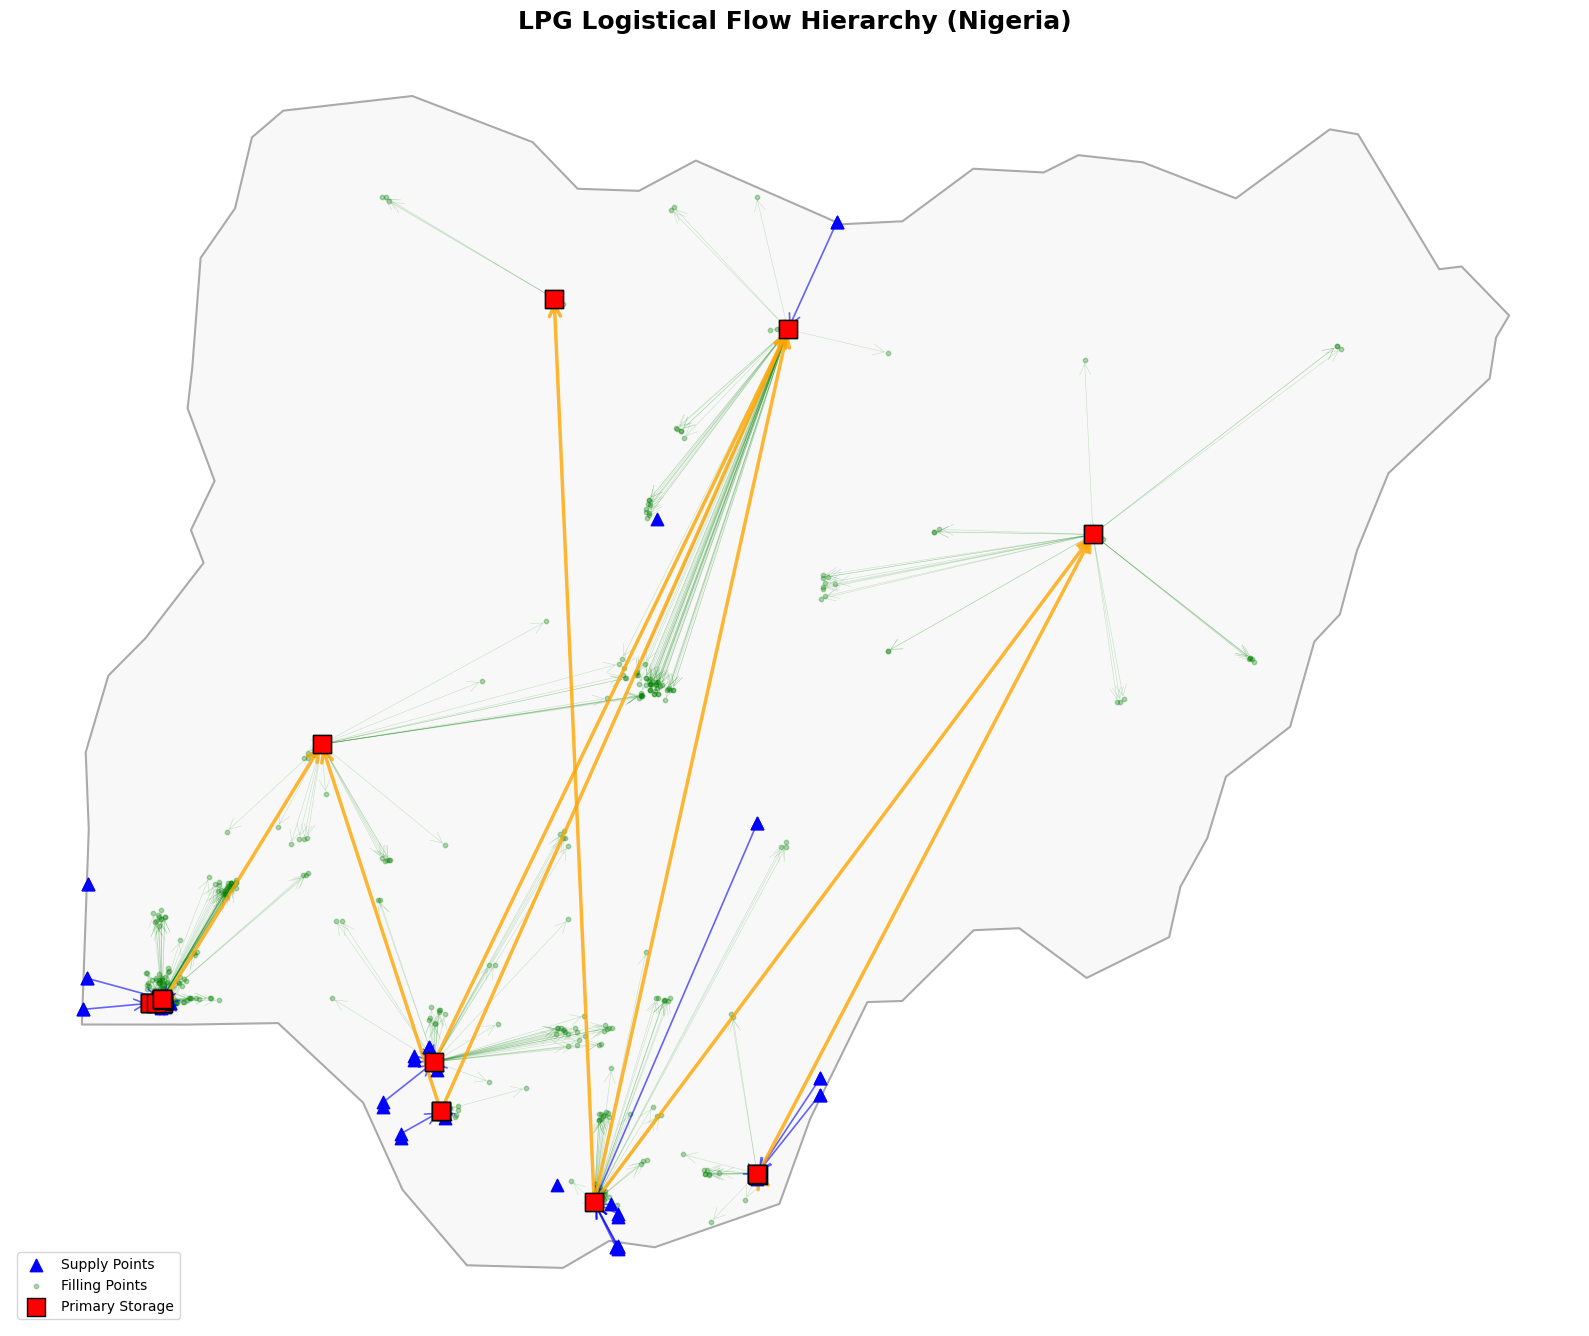

saved in: dataset_first_step\galga_flow.png


In [156]:
# Visualization of LPG supply chain with directional arrows:
# Blue: Source to Storage | Orange: Rebalancing | Green: Storage to Filling
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import pandas as pd
import numpy as np
import warnings

# Plot parameters
flow_figsize = (16, 16)
plot_bar_width = 0.2
nigeria_geojson_url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/NGA.geo.json"

warnings.filterwarnings('ignore', message='Geometry is in a geographic CRS.*')

print("\n=== Generating directional logistical flows map ===")

# 1. Load Data & Align CRS
ps = gpd.read_file(beginning_path, layer="primary_storage")
filling = gpd.read_file(filling_assigned_path)

# Ensure CRS alignment
if filling.crs != ps.crs:
    filling = filling.to_crs(ps.crs)

# 2. Load Nigeria Background
nigeria_bg = gpd.read_file(nigeria_geojson_url).to_crs(ps.crs)
print("Background map downloaded.")

# 3. Collect Supply Layers
supply_layers = ['refineries', 'ports', 'gas_plants', 'border_points']
supply_list = []
for lyr in supply_layers:
    try:
        gdf = gpd.read_file(beginning_path, layer=lyr)
        if gdf.crs != ps.crs: gdf = gdf.to_crs(ps.crs)
        supply_list.append(gdf)
    except:
        continue

supply = pd.concat(supply_list, ignore_index=True) if supply_list else gpd.GeoDataFrame()
ps_dict = {row['id_supply']: row.geometry.centroid for _, row in ps.iterrows()}

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=flow_figsize)

# Plot Background
if nigeria_bg is not None and not nigeria_bg.empty:
    nigeria_bg.plot(ax=ax, color='#f8f8f8', edgecolor='#aaaaaa', linewidth=1.5, zorder=0)
else:
    ax.set_facecolor('#fafafa')

def draw_arrow(start, end, color, lw, alpha, zorder=2, head_width=0.08):
    """
    Draw a styled arrow between two point geometries on the map.
    Uses annotate for consistent arrowheads and z-order control.
    Skips drawing when either endpoint is missing.
    Designed for readable, thin flow overlays.
    """
    if start is None or end is None:
        return
    ax.annotate("", xy=(end.x, end.y), xytext=(start.x, start.y),
                arrowprops=dict(arrowstyle="->", color=color, lw=lw,
                                alpha=alpha, shrinkA=2, shrinkB=2,
                                mutation_scale=20), zorder=zorder)

# 4. Draw Flows as Arrows
# A. Supply -> Primary Storage (Blue)
for _, row in supply.iterrows():
    tid = str(row.get('tank_id_supply', ''))
    if tid in ps_dict:
        draw_arrow(row.geometry.centroid, ps_dict[tid], 'blue', 1.2, 0.6)

# B. Rebalancing (Orange) - Thicker arrows
if 'allocation_matrix' in globals() and 'n_storage' in globals():
    for i in range(n_storage):
        for j in range(n_storage):
            if i != j and allocation_matrix[i, j] > 0.001:
                draw_arrow(ps.iloc[i].geometry.centroid, ps.iloc[j].geometry.centroid,
                           'orange', 2.5, 0.8, zorder=3)

# C. Primary -> Filling (Green) - Subtle arrows
for _, row in filling.iterrows():
    tid = str(row.get('tank_id_supply', ''))
    if tid in ps_dict:
        draw_arrow(ps_dict[tid], row.geometry.centroid, 'green', 0.4, 0.2, zorder=1)

# 5. Plot Infrastructure Points
if not supply.empty:
    supply.centroid.plot(ax=ax, color='blue', marker='^', markersize=80, label='Supply Points', zorder=4)
filling.centroid.plot(ax=ax, color='green', marker='o', markersize=10, alpha=0.3, label='Filling Points', zorder=1)
ps.centroid.plot(ax=ax, color='red', marker='s', markersize=150, edgecolor='black', label='Primary Storage', zorder=5)

# Formatting
ax.set_title('LPG Logistical Flow Hierarchy (Nigeria)', fontsize=18, fontweight='bold')
ax.axis('off')
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='lower left', frameon=True)

plt.tight_layout()

plt.savefig(output_image_path, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

print(f"saved in: {output_image_path}")

In [157]:
# Final export of all layers to beginning.gpkg
actual_output_gpkg = output_gpkg
try:
    _write_layers(output_gpkg, layer_store)
except PermissionError:
    print(f"[warn] Cannot overwrite {output_gpkg}. Saving to {output_gpkg_alt.name} instead.")
    actual_output_gpkg = output_gpkg_alt
    _write_layers(actual_output_gpkg, layer_store)

print(f"\n✓ beginning.gpkg export completed")
print(f"  Output file: {actual_output_gpkg}")
for key, layer_name in layer_map:
    gdf = layer_store[key]
    print(f"  - Layer '{layer_name}': {len(gdf)} records, {len(gdf.columns)} fields")


✓ beginning.gpkg export completed
  Output file: dataset_first_step\beginning.gpkg
  - Layer 'refineries': 4 records, 24 fields
  - Layer 'ports': 11 records, 58 fields
  - Layer 'gas_plants': 5 records, 24 fields
  - Layer 'primary_storage': 19 records, 42 fields
  - Layer 'border_points': 6 records, 45 fields


## Cost distribution charts

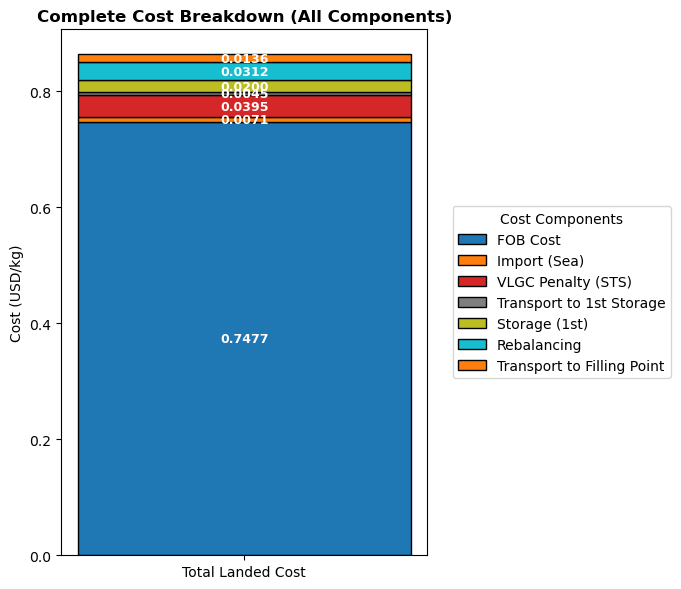

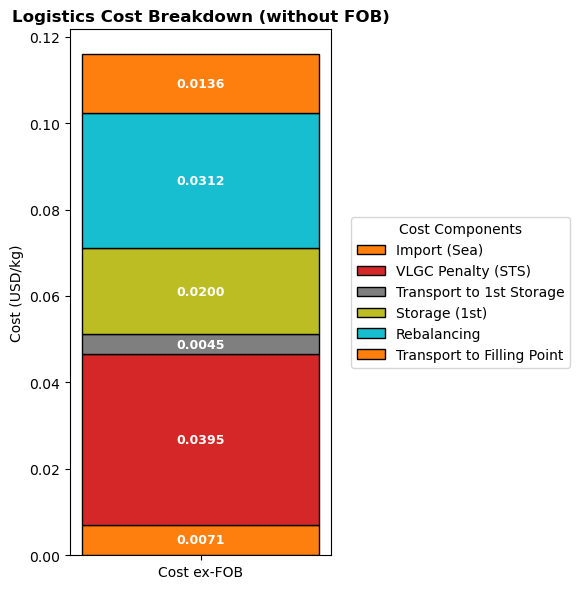

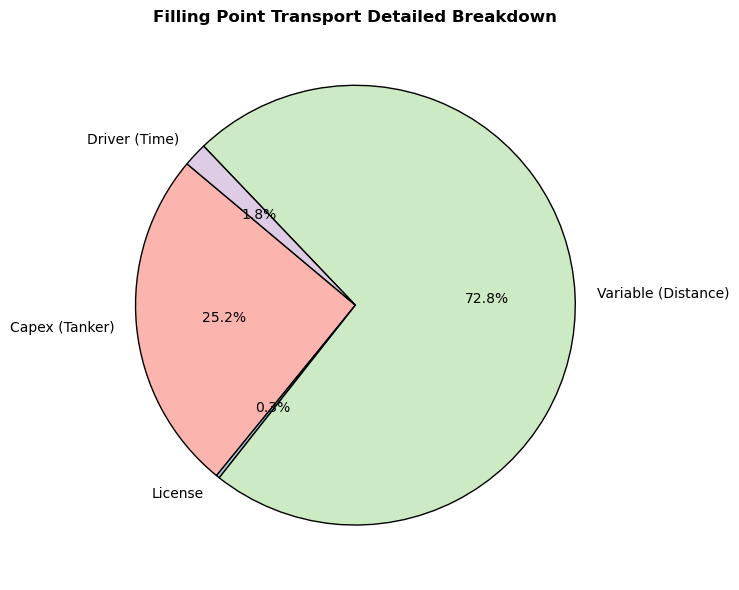

In [158]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path



# --- 1. COST COMPONENTS CALCULATION ---
filling_detailed = gpd.read_file(filling_assigned_path)

cols_to_drop = [c for c in ps_details.columns if c in filling_detailed.columns and c != 'tank_id_supply']
filling_clean = filling_detailed.drop(columns=cols_to_drop)

filling_detailed = filling_clean.merge(ps_details, left_on='tank_id_supply', right_on='id_supply', how='left')

avg_fob = filling_detailed['cost_fob'].mean()
avg_import_sea = filling_detailed['cost_import_sea'].mean()
avg_import_land = filling_detailed['cost_import_land'].mean()
avg_sts = filling_detailed['cost_sts'].mean()
avg_pre_bottling = filling_detailed['cost_pre_bottling'].mean()
avg_border_time = filling_detailed['cost_border_time'].mean()
avg_ferry = filling_detailed['cost_ferry'].mean()
avg_storage1 = filling_detailed['cost_storage_1'].mean()
avg_transp1 = filling_detailed['cost_transport_1'].mean()
avg_rebal = filling_detailed['cost_rebalancing'].mean()
avg_storage2 = filling_detailed['cost_storage_2'].mean()
avg_transp2 = filling_detailed['cost_transport_2'].mean()

cost_components = {
    'FOB Cost': avg_fob,
    'Import (Sea)': avg_import_sea,
    'Import (Land)': avg_import_land,
    'VLGC Penalty (STS)': avg_sts,
    'Pre-bottling': avg_pre_bottling,
    'Border Time': avg_border_time,
    'Ferry': avg_ferry,
    'Transport to 1st Storage': avg_transp1,
    'Storage (1st)': avg_storage1,
    'Rebalancing': avg_rebal,
    'Storage (2nd)': avg_storage2,
    'Transport to Filling Point': avg_transp2
}

# --- 2. DETAILED TRANSPORT COST BREAKDOWN ---
avg_dist_transp = filling['tank_distance'].mean()
avg_time_transp = filling['tank_traveltime'].mean()

avg_round_trip_km = 2.0 * avg_dist_leg2_km
trips_per_year = tanker_annual_km / avg_round_trip_km if avg_round_trip_km > 0 else 1

capex_per_kg = annual_capital_cost_usd / (effective_load_kg * trips_per_year)
license_per_kg = annual_license_cost_usd / (effective_load_kg * trips_per_year)

round_trip_hours = (avg_time_transp * 2.0 / 60.0) + fixed_loading_unloading_hours
round_trip_distance_km = 2.0 * avg_dist_transp

distance_var_per_kg = (variable_cost_per_km * round_trip_distance_km) / effective_load_kg
driver_per_kg = (driver_hourly_cost_usd * round_trip_hours) / effective_load_kg

transport_components = {
    'Capex (Tanker)': capex_per_kg,
    'License': license_per_kg,
    'Variable (Distance)': distance_var_per_kg,
    'Driver (Time)': driver_per_kg
}

# --- 3. PLOTTING IN 3 SEPARATE FIGURES ---
colors = plt.cm.tab10.colors
bar_width = plot_bar_width

plt.figure(figsize=(7, 6))
bottom_total = 0
for i, (key, value) in enumerate(cost_components.items()):
    if value > 0:
        plt.bar('Total Landed Cost', value, bottom=bottom_total, label=key, color=colors[i % 10], edgecolor='black', width=bar_width)
        plt.text(0, bottom_total + value / 2, f"{value:.4f}", ha='center', va='center', color='white', fontweight='bold', fontsize=9)
        bottom_total += value

plt.title('Complete Cost Breakdown (All Components)', fontweight='bold')
plt.ylabel('Cost (USD/kg)')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Cost Components")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
bottom_ex_fob = 0
for i, (key, value) in enumerate(cost_components.items()):
    if key != 'FOB Cost' and value > 0:
        plt.bar('Cost ex-FOB', value, bottom=bottom_ex_fob, label=key, color=colors[i % 10], edgecolor='black', width=bar_width)
        plt.text(0, bottom_ex_fob + value / 2, f"{value:.4f}", ha='center', va='center', color='white', fontweight='bold', fontsize=9)
        bottom_ex_fob += value

plt.title('Logistics Cost Breakdown (without FOB)', fontweight='bold')
plt.ylabel('Cost (USD/kg)')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Cost Components")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.pie(transport_components.values(), labels=transport_components.keys(), autopct='%1.1f%%',
        colors=plt.cm.Pastel1.colors, startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Filling Point Transport Detailed Breakdown', fontweight='bold')
plt.tight_layout()
plt.show()